# 01 · Exploratory Data Analysis (Sprint 2 · US 2.1)

**User story.** As the researcher, I want to understand the dataset structure and label distributions so that I can design an appropriate modeling and splitting strategy.

**Scope.** Speaker counts, native-language backgrounds, score distributions per level (sentence / word / phoneme) for **SpeechOcean762**, error-type frequencies for **L2-ARCTIC**, and an explicit register of class imbalance and edge cases. The two datasets have different label schemes, so they are analysed separately (Parts A and B) and compared only where it is meaningful (Part C).

**Outputs written by this notebook**
- figures → `results/figures/eda/`
- tables → `results/tables/eda/` (including `key_stats.json` and `imbalance_edge_case_register.csv`)
- narrative summary → `docs/eda_summary.md`

In [1]:
import sys, json, re, warnings
from pathlib import Path

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

from src.data.loaders import load_so762, load_so762_experts, load_l2arctic, ADULT_AGE_MIN
from src.data import eda_utils as eu

warnings.filterwarnings("ignore", category=FutureWarning)
eu.set_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
pd.set_option("display.max_rows", 80)

KEY = {}          # headline numbers -> results/tables/eda/key_stats.json
IMBALANCE = {}    # target name -> eu.imbalance_summary(...) for every label we might model
print("repo:", REPO)

repo: /sessions/rcw-01gomj9way6vkau3uc5comir/mnt/esl-pronunciation-assessment


---
# Part A · SpeechOcean762

5,000 utterances, 250 Mandarin-L1 speakers (half children/teens, half adults), scored by **five experts** at sentence, word and phoneme level. The release ships an **official train/test split** (2,500 / 2,500 utterances) which we keep as the test set.

## A1 · Structure, speakers and the official split

In [2]:
so = load_so762()
utts, words, phones = so.utts, so.words, so.phones
ex = load_so762_experts()

print(f"utterances={len(utts):,}   words={len(words):,}   phone tokens={len(phones):,}")
print(f"expert-level rows: sentence={len(ex.sent):,}  word={len(ex.words):,}  phone={len(ex.phones):,}  "
      f"(word strings that failed to parse: {ex.n_phone_mismatch})")

spk = utts.drop_duplicates("speaker")[["speaker", "split", "gender", "age", "age_group"]].reset_index(drop=True)
overlap = set(spk.loc[spk.split == "train", "speaker"]) & set(spk.loc[spk.split == "test", "speaker"])
per_spk = utts.groupby("speaker").size()

split_tbl = utts.groupby("split").agg(utterances=("utt_id", "size"), speakers=("speaker", "nunique"),
                                      hours=("duration_s", lambda s: s.sum() / 3600)).round(2)
display(split_tbl)
print("speakers present in BOTH official splits:", len(overlap))
print(f"utterances per speaker: min={per_spk.min()}  max={per_spk.max()}")
display(pd.crosstab(spk.split, [spk.age_group, spk.gender], margins=True))
print("age range:", spk.age.min(), "-", spk.age.max(), "| ages 16-18 present:", int(spk.age.between(16, 18).sum()))
display(spk.groupby("age_group").age.describe().round(1))

KEY["so762"] = {
    "utterances": len(utts), "speakers": int(spk.speaker.nunique()), "words": len(words), "phone_tokens": len(phones),
    "train_utts": int((utts.split == "train").sum()), "test_utts": int((utts.split == "test").sum()),
    "train_speakers": int((spk.split == "train").sum()), "test_speakers": int((spk.split == "test").sum()),
    "speakers_in_both_splits": len(overlap), "utts_per_speaker_min": int(per_spk.min()), "utts_per_speaker_max": int(per_spk.max()),
    "child_speakers": int((spk.age_group == "child/teen").sum()), "adult_speakers": int((spk.age_group == "adult").sum()),
}

utterances=5,000   words=31,816   phone tokens=94,445
expert-level rows: sentence=25,000  word=159,080  phone=472,225  (word strings that failed to parse: 0)


,utterances,speakers,hours
split,,,
test,2500,125,2.69
train,2500,125,2.88


speakers present in BOTH official splits: 0
utterances per speaker: min=20  max=20


age_group adult     child/teen      All
gender        f   m          f   m     
split                                  
test         31  30         27  37  125
train        41  26         26  32  125
All          72  56         53  69  250

age range: 6 - 43 | ages 16-18 present: 0


,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
adult,128.0,23.9,4.9,19.0,20.0,22.0,26.0,43.0
child/teen,122.0,9.3,2.9,6.0,7.0,9.0,11.0,15.0


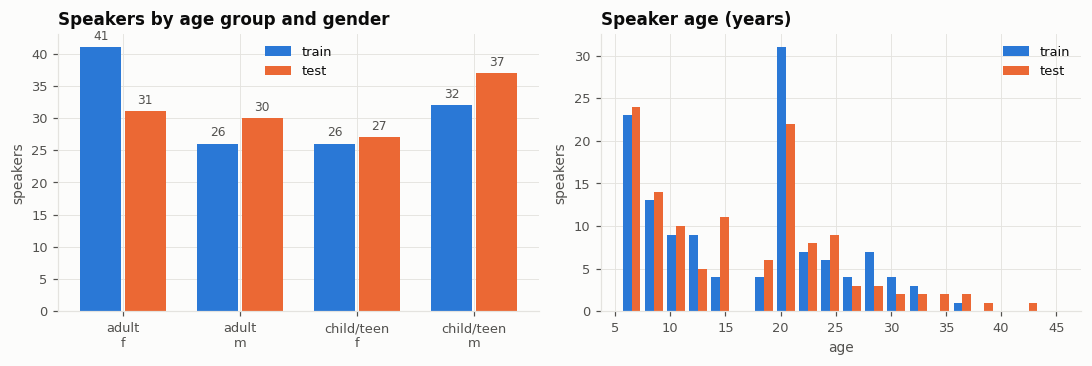

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
ct = pd.crosstab([spk.age_group, spk.gender], spk.split)
x, w = np.arange(len(ct)), 0.38
for i, s in enumerate(["train", "test"]):
    axes[0].bar(x + (i - 0.5) * w, ct[s], w * 0.92, color=eu.SPLIT_COLOR[s], label=s)
axes[0].set_xticks(x, [f"{a}\n{g}" for a, g in ct.index])
axes[0].set_title("Speakers by age group and gender")
axes[0].set_ylabel("speakers")
axes[0].legend()
eu.label_bars(axes[0])

bins = np.arange(5.5, 46.5, 2)
axes[1].hist([spk.age[spk.split == "train"], spk.age[spk.split == "test"]], bins=bins,
             color=[eu.SPLIT_COLOR["train"], eu.SPLIT_COLOR["test"]], label=["train", "test"])
axes[1].set_title("Speaker age (years)")
axes[1].set_xlabel("age"); axes[1].set_ylabel("speakers"); axes[1].legend()
fig.tight_layout()
eu.save_fig(fig, "a1_so762_speakers"); plt.show()

## A2 · Audio properties

sample rates: {16000: 5000} | channels: {1: 5000} | sample width (bytes): {2: 5000}


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,2500.0,3.88,1.40,1.79,2.95,3.50,4.38,12.23
train,2500.0,4.14,2.02,1.59,3.00,3.55,4.53,20.41


,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
adult,2560.0,4.44,2.13,1.88,3.11,3.76,4.97,20.41
child/teen,2440.0,3.56,1.05,1.59,2.86,3.34,4.03,11.12


,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
adult,2560.0,5.22,1.55,1.12,4.15,5.37,6.32,9.70
child/teen,2440.0,4.77,1.19,0.98,3.95,4.71,5.56,9.08


clips < 1 s: 0   clips > 20 s: 1   total hours: 5.57


,utt_id,speaker,split,text,duration_s,n_phones
59,000050175,0005,train,GOOD JOB,1.590,6
18,000010168,0001,train,BYE,1.670,2
3139,030750170,3075,test,THEY WILL BE THE HILL,1.792,12
1796,014350157,1435,train,HOW ARE WE GOING,1.840,9
2584,024380154,2438,test,CALL ME IF YOU DO,1.876,11


,utt_id,speaker,split,text,duration_s,n_phones
3885,070010006,7001,train,WHAT HE WAS TALKING ABOUT WAS SPORTS IN GENERAL,20.408,33
3884,070010005,7001,train,MOSTLY THE AMERICAN COMMUNITY IN EUROPE FOLLOW...,19.903,42
3894,070010015,7001,train,SHE LOOKED ANXIOUSLY AT THE HOUSE AND STARTED,19.735,30
3895,070010016,7001,train,THEY MAY MAKE ME MORE UNHAPPY THAN I AM,19.011,24
3922,080020003,8002,train,NATIONALLY THOUGH THE TREND IS BEGINNING TO TU...,17.106,39


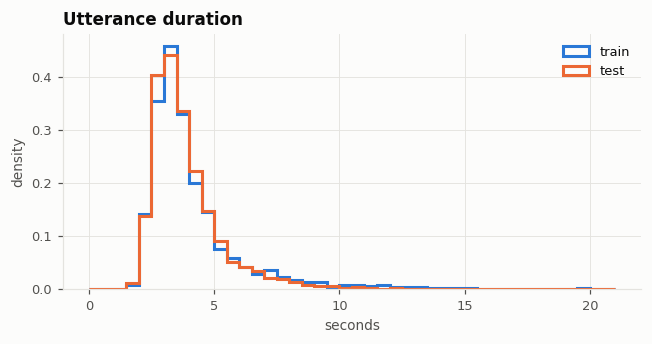

In [4]:
print("sample rates:", utts.sample_rate.value_counts().to_dict(), "| channels:", utts.channels.value_counts().to_dict(),
      "| sample width (bytes):", utts.sample_width.value_counts().to_dict())
display(utts.groupby("split").duration_s.describe().round(2))
display(utts.groupby("age_group").duration_s.describe().round(2))
utts["phones_per_sec"] = utts.n_phones / utts.duration_s
display(utts.groupby("age_group").phones_per_sec.describe().round(2))

short, long_ = utts[utts.duration_s < 1.0], utts[utts.duration_s > 20]
print(f"clips < 1 s: {len(short)}   clips > 20 s: {len(long_)}   total hours: {utts.duration_s.sum() / 3600:.2f}")
display(utts.nsmallest(5, "duration_s")[["utt_id", "speaker", "split", "text", "duration_s", "n_phones"]])
display(utts.nlargest(5, "duration_s")[["utt_id", "speaker", "split", "text", "duration_s", "n_phones"]])

fig, ax = plt.subplots(figsize=(6, 3.2))
for s in ["train", "test"]:
    ax.hist(utts.loc[utts.split == s, "duration_s"], bins=np.arange(0, utts.duration_s.max() + 1, 0.5), density=True,
            histtype="step", linewidth=2, color=eu.SPLIT_COLOR[s], label=s)
ax.set_title("Utterance duration"); ax.set_xlabel("seconds"); ax.set_ylabel("density"); ax.legend()
fig.tight_layout(); eu.save_fig(fig, "a2_so762_duration"); plt.show()

KEY["so762"].update({"hours": round(float(utts.duration_s.sum() / 3600), 2), "sample_rates": {str(k): int(v) for k, v in utts.sample_rate.value_counts().items()},
                     "dur_min_s": float(utts.duration_s.min()), "dur_max_s": float(utts.duration_s.max()), "dur_median_s": float(utts.duration_s.median())})

## A3 · Prompt text overlap

Each speaker reads 20 prompts. A speaker-independent split does **not** make the text disjoint, so we measure how much prompt text is shared across the official train and test sets.

In [5]:
txt = utts.groupby("text").agg(n_utts=("utt_id", "size"), n_speakers=("speaker", "nunique"),
                               splits=("split", lambda s: "+".join(sorted(set(s)))))
train_texts = set(utts.loc[utts.split == "train", "text"])
test_in_train = utts[(utts.split == "test") & utts.text.isin(train_texts)]
print(f"unique prompt texts: {len(txt):,} for {len(utts):,} utterances")
print("prompts read by more than one speaker:", int((txt.n_speakers > 1).sum()))
print("prompts that occur in both train and test:", int((txt.splits == "test+train").sum()))
print(f"test utterances whose prompt text also occurs in train: {len(test_in_train)} ({len(test_in_train) / (utts.split == 'test').sum():.1%})")
display(txt.sort_values("n_utts", ascending=False).head(8))
display(utts.groupby("age_group").n_words.describe().round(1))

KEY["so762"].update({"unique_prompts": int(len(txt)), "prompts_shared_across_splits": int((txt.splits == "test+train").sum()),
                     "test_utts_prompt_seen_in_train": int(len(test_in_train))})

unique prompt texts: 4,947 for 5,000 utterances
prompts read by more than one speaker: 53
prompts that occur in both train and test: 52
test utterances whose prompt text also occurs in train: 52 (2.1%)


,n_utts,n_speakers,splits
text,,,
LOOK AT THIS BIG JEEP,2,2,test+train
WELL MOTHER,2,2,test+train
MY PEOPLE WILL BRING YOU TO THE SHIP,2,2,test+train
AFTER ALL WHAT DID IT MATTER,2,2,test+train
SHE LOOKED ANXIOUSLY AT THE HOUSE AND STARTED,2,2,test+train
SHE WOULD BE SORRY FOR HIS DEATH,2,2,test+train
DID I PLEASE YOU,2,2,test+train
SOMEBODY LET ME KNOW WHEN IT'S OVER,2,2,test+train


,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
adult,2560.0,7.1,1.6,4.0,6.0,7.0,8.0,10.0
child/teen,2440.0,5.6,1.8,1.0,4.0,5.0,7.0,10.0


## A4 · Sentence-level scores (accuracy, fluency, prosodic, total, completeness)

Distributions are shown per official split. The KS test checks whether train and test were drawn from the same distribution, which matters for how comparable validation and test results will be.

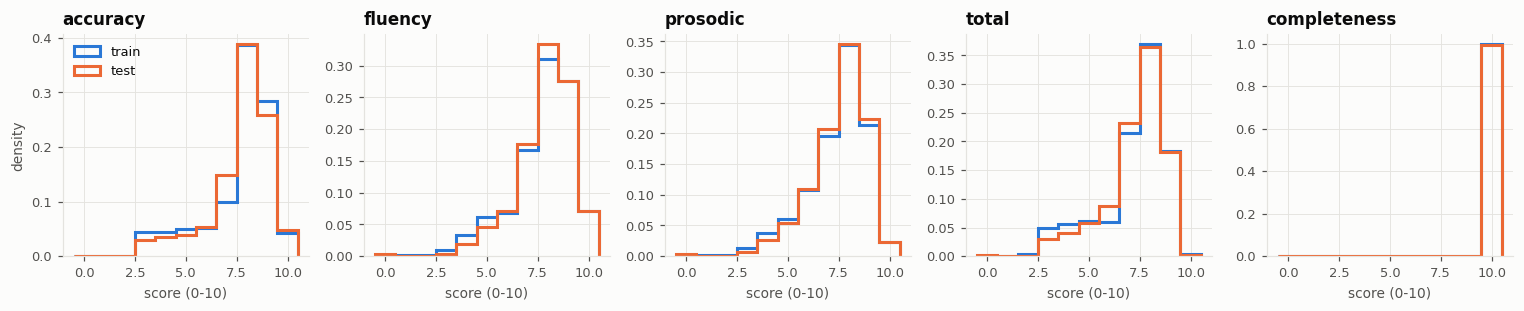

,metric,split,mean,std,min,median,max,skew,share_ge9,share_le4
0,accuracy,train,7.618,1.695,3.0,8.0,10.0,-1.286,0.326,0.088
1,accuracy,test,7.696,1.539,1.0,8.0,10.0,-1.313,0.307,0.064
2,fluency,train,7.728,1.555,1.0,8.0,10.0,-1.061,0.348,0.047
3,fluency,test,7.840,1.425,0.0,8.0,10.0,-1.241,0.347,0.027
4,prosodic,train,7.422,1.503,1.0,8.0,10.0,-1.011,0.237,0.055
5,prosodic,test,7.502,1.433,0.0,8.0,10.0,-1.169,0.245,0.038
6,total,train,7.181,1.669,2.0,8.0,10.0,-1.128,0.186,0.109
7,total,test,7.263,1.550,0.0,8.0,10.0,-1.317,0.184,0.075
8,completeness,train,9.994,0.108,6.7,10.0,10.0,-21.022,0.997,0.000
9,completeness,test,9.966,0.512,0.0,10.0,10.0,-17.413,0.994,0.002


,KS statistic,p-value
accuracy,0.0360,0.0783
fluency,0.0360,0.0783
prosodic,0.0220,0.5807
total,0.0380,0.0541
completeness,0.0048,1.0000


non-integer values: {'accuracy': 0, 'fluency': 0, 'prosodic': 0, 'total': 0, 'completeness': 14}
completeness value counts: {0.0: 5, 2.0: 1, 5.0: 1, 6.0: 1, 7.0: 4, 8.0: 4, 9.0: 9, 10.0: 4975}


In [6]:
SENT = ["accuracy", "fluency", "prosodic", "total", "completeness"]
fig, axes = plt.subplots(1, 5, figsize=(14, 2.9))
bins = np.arange(-0.5, 10.6, 1)
for ax, m in zip(axes, SENT):
    for s in ["train", "test"]:
        ax.hist(utts.loc[utts.split == s, m], bins=bins, density=True, histtype="step", linewidth=2,
                color=eu.SPLIT_COLOR[s], label=s)
    ax.set_title(m); ax.set_xlabel("score (0-10)")
axes[0].set_ylabel("density"); axes[0].legend()
fig.tight_layout(); eu.save_fig(fig, "a4_so762_sentence_scores"); plt.show()

rows = []
for m in SENT:
    for s in ["train", "test"]:
        v = utts.loc[utts.split == s, m]
        rows.append(dict(metric=m, split=s, mean=v.mean(), std=v.std(), min=v.min(), median=v.median(), max=v.max(),
                         skew=v.skew(), share_ge9=(v >= 9).mean(), share_le4=(v <= 4).mean()))
sent_desc = pd.DataFrame(rows)
display(sent_desc.round(3))
ks = {m: stats.ks_2samp(utts.loc[utts.split == "train", m], utts.loc[utts.split == "test", m]) for m in SENT}
ks_tbl = pd.DataFrame({m: {"KS statistic": r.statistic, "p-value": r.pvalue} for m, r in ks.items()}).T
display(ks_tbl.round(4))
eu.save_table(sent_desc, "so762_sentence_score_summary", index=False)

print("non-integer values:", {m: int((utts[m] % 1 != 0).sum()) for m in SENT})
print("completeness value counts:", utts.completeness.round().value_counts().sort_index().to_dict())

for m in SENT:
    IMBALANCE[f"so762 sentence {m}"] = eu.imbalance_summary(utts[m].round().astype(int).value_counts())

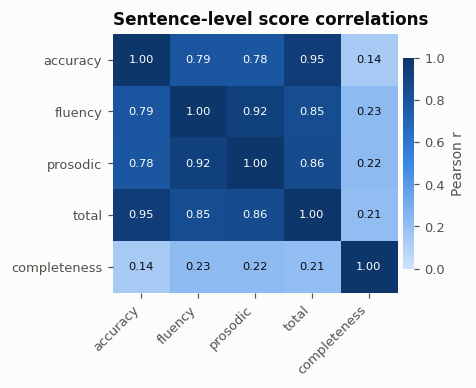

Mean score by age group and split:


accuracy  fluency  prosodic  total  completeness
age_group  split                                                  
adult      test       7.46     7.74      7.37   7.04         10.00
           train      7.15     7.41      7.08   6.72          9.99
child/teen test       7.92     7.93      7.63   7.48          9.93
           train      8.16     8.10      7.81   7.72         10.00

Share of low scores (accuracy <= 5) by age group:


split,test,train
age_group,,
adult,0.166,0.244
child/teen,0.043,0.017


In [7]:
corr = utts[SENT].corr()
fig, ax = plt.subplots(figsize=(4.4, 3.6))
eu.heatmap(ax, corr, fmt="{:.2f}", vmax=1.0, cbar_label="Pearson r")
ax.set_title("Sentence-level score correlations")
fig.tight_layout(); eu.save_fig(fig, "a4_so762_sentence_corr"); plt.show()

print("Mean score by age group and split:")
display(utts.groupby(["age_group", "split"])[SENT].mean().round(2))
print("Share of low scores (accuracy <= 5) by age group:")
display((utts.assign(low=utts.accuracy <= 5).groupby(["age_group", "split"]).low.mean().round(3)).unstack())

## A5 · Word-level scores (accuracy, stress, total)

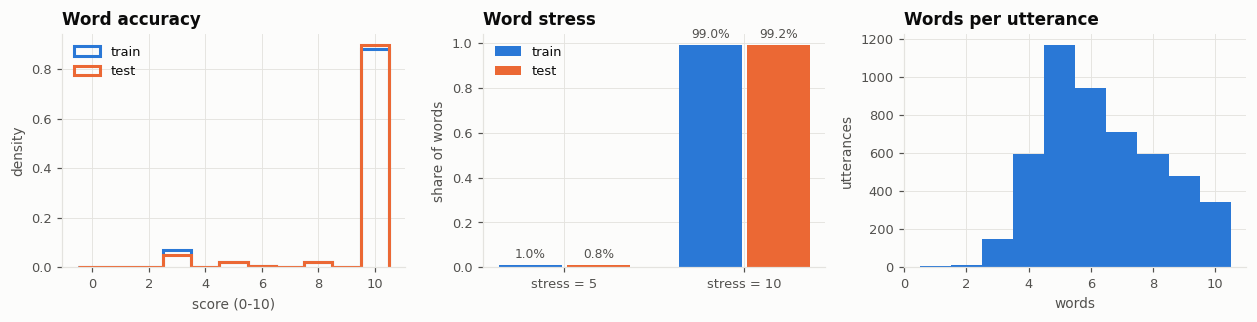

,words,mean_acc,share_acc10,share_acc_le6,share_stress5
split,,,,,
test,15967,9.437,0.897,0.081,0.008
train,15849,9.319,0.880,0.098,0.010


stress values: {10: 31529, 5: 287} | word accuracy unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
phones per word: mean=2.97  max=12   one-phone words: 1787


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.0))
bins = np.arange(-0.5, 10.6, 1)
for s in ["train", "test"]:
    axes[0].hist(words.loc[words.split == s, "accuracy"], bins=bins, density=True, histtype="step", linewidth=2,
                 color=eu.SPLIT_COLOR[s], label=s)
axes[0].set_title("Word accuracy"); axes[0].set_xlabel("score (0-10)"); axes[0].set_ylabel("density"); axes[0].legend()

stress_share = words.groupby("split").stress.value_counts(normalize=True).unstack()
xx, ww = np.arange(len(stress_share.columns)), 0.38
for i, s in enumerate(["train", "test"]):
    axes[1].bar(xx + (i - 0.5) * ww, stress_share.loc[s], ww * 0.92, color=eu.SPLIT_COLOR[s], label=s)
axes[1].set_xticks(xx, [f"stress = {int(c)}" for c in stress_share.columns])
axes[1].set_title("Word stress"); axes[1].set_ylabel("share of words"); axes[1].legend()
eu.label_bars(axes[1], fmt="{:.1%}")

axes[2].hist(utts.n_words, bins=np.arange(0.5, utts.n_words.max() + 1.5, 1), color=eu.CAT[0])
axes[2].set_title("Words per utterance"); axes[2].set_xlabel("words"); axes[2].set_ylabel("utterances")
fig.tight_layout(); eu.save_fig(fig, "a5_so762_word_scores"); plt.show()

wt = words.groupby("split").agg(words=("word", "size"), mean_acc=("accuracy", "mean"),
                                 share_acc10=("accuracy", lambda s: (s == 10).mean()),
                                 share_acc_le6=("accuracy", lambda s: (s <= 6).mean()),
                                 share_stress5=("stress", lambda s: (s == 5).mean()))
display(wt.round(3))
print("stress values:", words.stress.value_counts().to_dict(), "| word accuracy unique values:", sorted(words.accuracy.unique())[:14])
print(f"phones per word: mean={words.n_phones.mean():.2f}  max={words.n_phones.max()}   one-phone words: {(words.n_phones == 1).sum()}")

IMBALANCE["so762 word accuracy (0-10)"] = eu.imbalance_summary(words.accuracy.round().astype(int).value_counts())
IMBALANCE["so762 word stress (5/10)"] = eu.imbalance_summary(words.stress.astype(int).value_counts())
IMBALANCE["so762 word accuracy <= 6 vs > 6"] = eu.imbalance_summary((words.accuracy <= 6).map({True: "<=6", False: ">6"}).value_counts())
KEY["so762"].update({"share_word_stress_wrong": float((words.stress == 5).mean()), "share_word_acc10": float((words.accuracy == 10).mean()),
                     "share_word_acc_le6": float((words.accuracy <= 6).mean())})

## A6 · Phoneme-level scores

`scores.json` stores each phone's score as the **mean of five expert scores in {0, 1, 2}**, so the consensus value is a multiple of 0.2 rather than a clean 0/1/2 class. We look at the consensus values, the underlying expert labels, a few candidate binarisations, and per-phoneme difficulty.

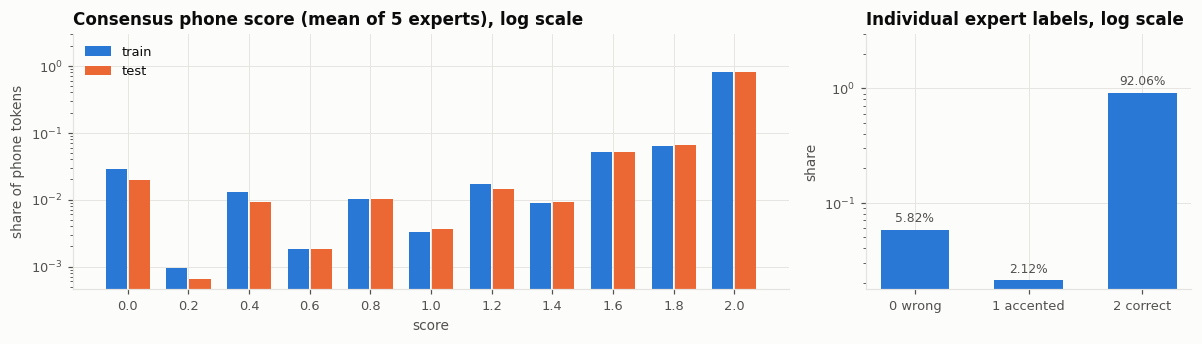

Prevalence of 'mispronounced' under candidate binarisations:


split,test,train,all
score < 0.5 (clearly wrong),0.0298,0.0423,0.0360
score < 1.0,0.0418,0.0545,0.0481
score < 1.5,0.0691,0.0841,0.0766
score < 2.0 (not unanimously correct),0.1873,0.1990,0.1932


expert-level label counts: {0: 27493, 1: 9996, 2: 434736}
consensus score values present: [np.float64(0.0), np.float64(0.2), np.float64(0.4), np.float64(0.6), np.float64(0.8), np.float64(1.0), np.float64(1.2), np.float64(1.4), np.float64(1.6), np.float64(1.8), np.float64(2.0)]


In [9]:
vals = phones.score.round(1)
share = vals.groupby(phones.split).value_counts(normalize=True).unstack(0).sort_index()
exp_share = ex.phones.score.value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [2.2, 1]})
xx, ww = np.arange(len(share)), 0.38
for i, s in enumerate(["train", "test"]):
    axes[0].bar(xx + (i - 0.5) * ww, share[s], ww * 0.92, color=eu.SPLIT_COLOR[s], label=s)
axes[0].set_xticks(xx, [f"{v:.1f}" for v in share.index])
axes[0].set_yscale("log"); axes[0].set_title("Consensus phone score (mean of 5 experts), log scale")
axes[0].set_xlabel("score"); axes[0].set_ylabel("share of phone tokens"); axes[0].legend()
axes[1].bar([0, 1, 2], exp_share.reindex([0, 1, 2]).to_numpy(), 0.6, color=eu.CAT[0])
axes[1].set_xticks([0, 1, 2], ["0 wrong", "1 accented", "2 correct"])
axes[1].set_yscale("log"); axes[1].set_title("Individual expert labels, log scale"); axes[1].set_ylabel("share")
eu.label_bars(axes[1], fmt="{:.2%}")
axes[0].set_ylim(top=3); axes[1].set_ylim(top=3)
fig.tight_layout(); eu.save_fig(fig, "a6_so762_phone_scores"); plt.show()

thr = {"score < 0.5 (clearly wrong)": 0.5, "score < 1.0": 1.0, "score < 1.5": 1.5, "score < 2.0 (not unanimously correct)": 2.0}
prev = pd.DataFrame({name: phones.groupby("split").score.apply(lambda s, t=t: (s < t).mean()) for name, t in thr.items()}).T
prev["all"] = pd.Series({name: (phones.score < t).mean() for name, t in thr.items()})
print("Prevalence of 'mispronounced' under candidate binarisations:")
display(prev.round(4))
print("expert-level label counts:", ex.phones.score.value_counts().sort_index().to_dict())
print("consensus score values present:", sorted(vals.unique()))
eu.save_table(prev, "so762_phone_binarisation_prevalence")

IMBALANCE["so762 phone expert label (0/1/2)"] = eu.imbalance_summary(ex.phones.score.value_counts())
IMBALANCE["so762 phone consensus < 1.0 vs >= 1.0"] = eu.imbalance_summary((phones.score < 1).map({True: "<1", False: ">=1"}).value_counts())
IMBALANCE["so762 phone consensus < 0.5 vs >= 0.5"] = eu.imbalance_summary((phones.score < 0.5).map({True: "<0.5", False: ">=0.5"}).value_counts())
KEY["so762"].update({"expert_phone_label_share": {str(k): float(v) for k, v in exp_share.items()},
                     "phone_share_lt05": float((phones.score < 0.5).mean()), "phone_share_lt10": float((phones.score < 1).mean()),
                     "phone_share_lt15": float((phones.score < 1.5).mean()), "phone_share_lt20": float((phones.score < 2).mean()),
                     "phone_share_eq20": float((phones.score == 2).mean())})

39 base phonemes; token counts range 25 - 8830


,n,mean_score,share_lt1,share_lt15,is_vowel
phone_base,,,,,
ZH,25,1.264,0.280,0.560,False
TH,649,1.672,0.105,0.176,False
Z,2529,1.728,0.050,0.120,False
EY,1605,1.749,0.109,0.166,True
EH,2538,1.766,0.090,0.146,True
UH,1131,1.782,0.075,0.098,True
ER,1327,1.784,0.092,0.128,True
OY,56,1.786,0.089,0.107,True
AW,690,1.801,0.074,0.114,True


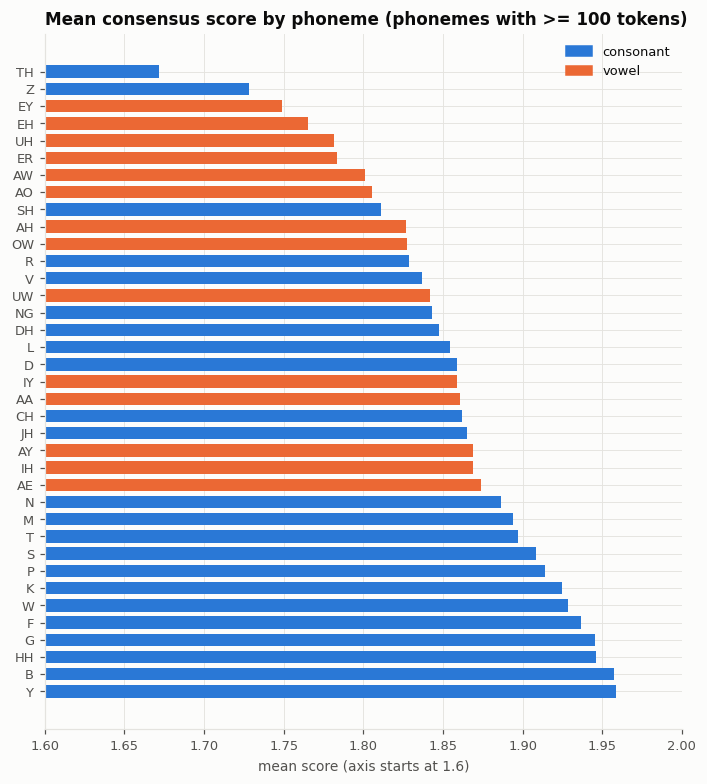

Vowel score by lexical stress digit:


,size,mean
stress,,
0,32396,1.843
1,4913,1.786
2,96,1.558


phone tokens with a 'pronounced-phone' annotation (score < 0.5): 3,403 (3.60%)
   '<DEL>' (deleted): 846 | '<unk>' (unrecognisable): 820 | accented variant '*': 225
distinct canonical->pronounced pairs: 472


,count
AH -> <unk>,106
T -> <DEL>,101
N -> <DEL>,78
IH -> <DEL>,71
D -> <DEL>,65
Z -> <DEL>,62
IH -> <unk>,61
AH -> <DEL>,58
N -> <unk>,56
S -> <DEL>,51


In [10]:
pt = phones.groupby("phone_base").agg(n=("score", "size"), mean_score=("score", "mean"),
                                       share_lt1=("score", lambda s: (s < 1).mean()),
                                       share_lt15=("score", lambda s: (s < 1.5).mean())).sort_values("mean_score")
pt["is_vowel"] = pt.index.isin(eu.VOWELS)
print(f"{len(pt)} base phonemes; token counts range {pt.n.min()} - {pt.n.max()}")
display(pt.head(10).round(3))

ptp = pt[pt.n >= 100]      # ZH (n=25) is omitted: too few tokens to rank
fig, ax = plt.subplots(figsize=(6.5, 7.2))
colors = [eu.CAT[1] if v else eu.CAT[0] for v in ptp.is_vowel]
ax.barh(ptp.index, ptp.mean_score, color=colors, height=0.72)
ax.set_xlim(1.6, 2.0); ax.invert_yaxis()
ax.set_title("Mean consensus score by phoneme (phonemes with >= 100 tokens)"); ax.set_xlabel("mean score (axis starts at 1.6)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=eu.CAT[0], label="consonant"), Patch(color=eu.CAT[1], label="vowel")], loc="upper right")
fig.tight_layout(); eu.save_fig(fig, "a6_so762_phone_difficulty"); plt.show()
eu.save_table(pt, "so762_phone_difficulty")

ph_v = phones[phones.phone_base.isin(eu.VOWELS)].copy()
ph_v["stress"] = ph_v.phone.str.extract(r"(\d)$")[0]
print("Vowel score by lexical stress digit:")
display(ph_v.groupby("stress").score.agg(["size", "mean"]).round(3))

mp = phones[phones.pronounced.notna()]
print(f"phone tokens with a 'pronounced-phone' annotation (score < 0.5): {len(mp):,} ({len(mp) / len(phones):.2%})")
print("   '<DEL>' (deleted):", int((mp.pronounced == "<DEL>").sum()), "| '<unk>' (unrecognisable):", int((mp.pronounced == "<unk>").sum()), "| accented variant '*':", int(mp.pronounced.str.contains(r"\*", regex=True).sum()))
pairs = (mp.phone_base + " -> " + mp.pronounced.str.replace(r"\d", "", regex=True)).value_counts()
print("distinct canonical->pronounced pairs:", len(pairs))
display(pairs.head(12).to_frame("count"))
KEY["so762"].update({"n_base_phones": int(len(pt)), "phone_tokens_with_pronounced_label": int(len(mp))})

## A7 · Annotator reliability (label-noise ceiling)

`scores-detail.json` keeps the five experts' individual scores. Agreement between experts bounds what any model can achieve against the consensus label. The five rater slots show large, consistent severity differences (see the table after the agreement results), so raters are treated as fixed individuals and **ICC(2,1)** (absolute agreement) is reported alongside the pairwise and leave-one-out correlations. ICC(1,1) is kept for reference.

In [11]:
def wide(df, col, key=None):
    d = df if key is None else df.assign(_k=key(df))
    return d.pivot(index="utt_id" if key is None else "_k", columns="expert", values=col)

rows = []
for m in ["accuracy", "fluency", "prosodic", "total"]:
    wd = wide(ex.sent, m)
    row = dict(level="sentence", target=m, n_items=len(wd), pairwise_r=eu.mean_pairwise_pearson(wd),
               leave_one_out_r=eu.leave_one_out_pearson(wd), icc_2_1=eu.icc_2_1(wd), icc_1_1=eu.icc_1_1(wd))
    if m != "total":
        row["mean_pairwise_QWK"] = np.mean([cohen_kappa_score(wd[a].astype(int), wd[b].astype(int), weights="quadratic")
                                            for a, b in combinations(wd.columns, 2)])
    rows.append(row)
wk = lambda d: d.utt_id + "_" + d.word_idx.astype(str)
for m in ["accuracy", "stress", "total"]:
    wd = wide(ex.words, m, key=wk)
    row = dict(level="word", target=m, n_items=len(wd), pairwise_r=eu.mean_pairwise_pearson(wd),
               leave_one_out_r=eu.leave_one_out_pearson(wd), icc_2_1=eu.icc_2_1(wd), icc_1_1=eu.icc_1_1(wd))
    if m != "total":
        row["mean_pairwise_QWK"] = np.mean([cohen_kappa_score(wd[a].astype(int), wd[b].astype(int), weights="quadratic")
                                            for a, b in combinations(wd.columns, 2)])
    rows.append(row)

pc = (ex.phones.groupby(["utt_id", "word_idx", "phone_idx"]).score.value_counts().unstack(fill_value=0)
      .reindex(columns=[0, 1, 2], fill_value=0))
assert (pc.sum(axis=1) == 5).all(), "every phone token should have exactly 5 expert labels"
rows.append(dict(level="phone", target="score (0/1/2)", n_items=len(pc), fleiss_kappa=eu.fleiss_kappa(pc.to_numpy()),
                 pairwise_exact_agreement=eu.pairwise_exact_agreement(pc.to_numpy())))
agree = pd.DataFrame(rows)
display(agree.round(3))
eu.save_table(agree, "so762_annotator_agreement", index=False)

# Binary view of phone labels (mispronounced = any rating below 2 by majority) shows how agreement drops for rare classes
maj_wrong = (pc[0] >= 3)
print(f"phone tokens where >= 3 of 5 experts say 'wrong' (0): {int(maj_wrong.sum()):,} ({maj_wrong.mean():.2%})")
print(f"phone tokens where experts are NOT unanimous: {(pc.max(axis=1) < 5).mean():.1%}")
KEY["so762"]["agreement"] = {f"{r['level']}_{r['target']}": {k: (None if pd.isna(v) else round(float(v), 4)) for k, v in r.items()
                                                              if k in ("pairwise_r", "leave_one_out_r", "icc_2_1", "icc_1_1", "mean_pairwise_QWK", "fleiss_kappa", "pairwise_exact_agreement")}
                             for r in rows}
KEY["so762"].update({"phone_majority_wrong_share": float(maj_wrong.mean()), "phone_non_unanimous_share": float((pc.max(axis=1) < 5).mean())})

,level,target,n_items,pairwise_r,leave_one_out_r,icc_2_1,icc_1_1,mean_pairwise_QWK,fleiss_kappa,pairwise_exact_agreement
0,sentence,accuracy,5000,0.661,0.766,0.605,0.599,0.605,NaN,NaN
1,sentence,fluency,5000,0.690,0.788,0.514,0.488,0.538,NaN,NaN
2,sentence,prosodic,5000,0.669,0.772,0.513,0.489,0.531,NaN,NaN
3,sentence,total,5000,0.708,0.802,0.635,0.627,NaN,NaN,NaN
4,word,accuracy,31816,0.623,0.735,0.602,0.600,0.608,NaN,NaN
5,word,stress,31816,0.192,0.284,0.129,0.114,0.148,NaN,NaN
6,word,total,31816,0.636,0.745,0.619,0.618,NaN,NaN,NaN
7,phone,score (0/1/2),94445,NaN,NaN,NaN,NaN,NaN,0.464,0.92


phone tokens where >= 3 of 5 experts say 'wrong' (0): 4,489 (4.75%)
phone tokens where experts are NOT unanimous: 16.9%


In [12]:
# How was the published consensus (scores.json) derived from the five experts?
cons = utts.set_index("utt_id")
rows = []
for m in ["accuracy", "fluency", "prosodic", "total"]:
    wd = wide(ex.sent, m)
    c = cons.loc[wd.index, m]
    rows.append(dict(metric=m, equals_median=(c == wd.median(axis=1)).mean(), equals_rounded_mean=(c == wd.mean(axis=1).round()).mean(),
                     corr_with_mean=np.corrcoef(c, wd.mean(axis=1))[0, 1]))
display(pd.DataFrame(rows).round(3))
print("Mean expert score by expert index (is expert order consistent?):")
display(ex.sent.groupby("expert")[["accuracy", "fluency", "prosodic", "total"]].mean().round(2))

,metric,equals_median,equals_rounded_mean,corr_with_mean
0,accuracy,1.000,0.746,0.959
1,fluency,1.000,0.698,0.953
2,prosodic,1.000,0.712,0.951
3,total,0.274,0.601,0.959


Mean expert score by expert index (is expert order consistent?):


,accuracy,fluency,prosodic,total
expert,,,,
0,8.06,8.31,8.19,8.10
1,7.47,8.08,7.69,7.54
2,8.13,8.58,8.03,8.15
3,6.87,6.70,6.30,6.79
4,7.51,6.64,6.55,7.27


## A8 · How much of the score variance is between speakers?

If much of the variance sits between speakers, a speaker-independent split is essential (otherwise the model can memorise speaker identity), and splits should be stratified so that no partition ends up with, e.g., only adults.

,target,speakers,between_speaker_variance_share
0,accuracy,250,0.701
1,fluency,250,0.761
2,prosodic,250,0.777
3,total,250,0.734


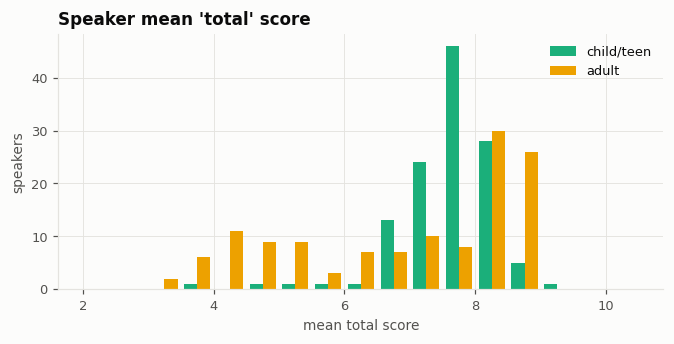

size  mean   std
age_group  split                  
adult      test     61  7.04  1.63
           train    67  6.72  1.84
child/teen test     64  7.48  0.84
           train    58  7.72  0.58

Speaker-level train vs test comparison of mean 'total' score (Mann-Whitney U; the speaker is the independent unit):


,group,n_train,n_test,mean_train,mean_test,p_value
0,all speakers,125,125,7.1812,7.2632,0.9735
1,adult,67,61,6.7164,7.0402,0.2621
2,child/teen,58,64,7.7181,7.4758,0.2711


In [13]:
t = utts.sort_values("utt_id").assign(slot=lambda d: d.groupby("speaker").cumcount())
rows = []
for m in ["accuracy", "fluency", "prosodic", "total"]:
    wd = t.pivot(index="speaker", columns="slot", values=m).dropna()
    rows.append(dict(target=m, speakers=len(wd), between_speaker_variance_share=eu.icc_1_1(wd)))
spk_var = pd.DataFrame(rows)
display(spk_var.round(3))

spk_mean = utts.groupby("speaker").agg(total=("total", "mean"), age_group=("age_group", "first"), split=("split", "first"))
fig, ax = plt.subplots(figsize=(6.2, 3.2))
ag = ["child/teen", "adult"]
ax.hist([spk_mean.loc[spk_mean.age_group == g, "total"] for g in ag], bins=np.arange(2, 10.6, 0.5),
        color=[eu.CAT[2], eu.CAT[3]], label=ag)
ax.set_title("Speaker mean 'total' score"); ax.set_xlabel("mean total score"); ax.set_ylabel("speakers"); ax.legend()
fig.tight_layout(); eu.save_fig(fig, "a8_so762_speaker_means"); plt.show()
display(spk_mean.groupby(["age_group", "split"]).total.agg(["size", "mean", "std"]).round(2))
print("Speaker-level train vs test comparison of mean 'total' score (Mann-Whitney U; the speaker is the independent unit):")
shift_rows = []
for grp, g in [("all speakers", spk_mean)] + [(a, spk_mean[spk_mean.age_group == a]) for a in ["adult", "child/teen"]]:
    a_, b_ = g.loc[g.split == "train", "total"], g.loc[g.split == "test", "total"]
    r = stats.mannwhitneyu(a_, b_)
    shift_rows.append(dict(group=grp, n_train=len(a_), n_test=len(b_), mean_train=a_.mean(), mean_test=b_.mean(), p_value=r.pvalue))
shift_tbl = pd.DataFrame(shift_rows)
display(shift_tbl.round(4))
KEY["so762"]["speaker_level_split_shift"] = {r.group: {"mean_train": round(float(r.mean_train), 3), "mean_test": round(float(r.mean_test), 3), "p": round(float(r.p_value), 4)} for r in shift_tbl.itertuples()}
KEY["so762"]["between_speaker_variance_share"] = {r.target: round(float(r.between_speaker_variance_share), 4) for r in spk_var.itertuples()}

## A9 · SpeechOcean762 imbalance summary

`majority_share` is the share of the most common class; `imbalance_ratio` is majority count / minority count; `norm_entropy` is 1.0 for a perfectly balanced target and approaches 0 for a degenerate one.

In [14]:
imb_so = pd.DataFrame({k: v for k, v in IMBALANCE.items() if k.startswith("so762")}).T
display(imb_so.assign(majority_share=imb_so.majority_share.astype(float).round(3), minority_share=imb_so.minority_share.astype(float).round(4),
                      imbalance_ratio=imb_so.imbalance_ratio.astype(float).round(1), norm_entropy=imb_so.norm_entropy.astype(float).round(3)))
eu.save_table(imb_so, "so762_imbalance_summary")

,n_classes,n,majority,majority_share,minority,minority_share,imbalance_ratio,norm_entropy
so762 sentence accuracy,9,5000,8,0.387,1,0.0002,1936.0,0.756
so762 sentence fluency,11,5000,8,0.322,2,0.0010,321.8,0.712
so762 sentence prosodic,11,5000,8,0.344,1,0.0010,344.2,0.709
so762 sentence total,11,5000,8,0.367,1,0.0006,612.0,0.704
so762 sentence completeness,8,5000,10,0.995,5,0.0002,4975.0,0.019
so762 word accuracy (0-10),11,31816,10,0.888,4,0.0002,4709.8,0.208
so762 word stress (5/10),2,31816,10,0.991,5,0.0090,109.9,0.074
so762 word accuracy <= 6 vs > 6,2,31816,>6,0.910,<=6,0.0896,10.2,0.435
so762 phone expert label (0/1/2),3,472225,2,0.921,1,0.0212,43.5,0.294
so762 phone consensus < 1.0 vs >= 1.0,2,94445,>=1,0.952,<1,0.0481,19.8,0.278


PosixPath('/sessions/rcw-01gomj9way6vkau3uc5comir/mnt/esl-pronunciation-assessment/results/tables/eda/so762_imbalance_summary.csv')

### Part A takeaways
- The official split is speaker-disjoint (125 train / 125 test speakers, 20 utterances each) and roughly balanced for age group and gender; about half the speakers are children/teens.
- Sentence scores are left-skewed (mode 8). **Completeness** is 10 for 99.5% of utterances and **word stress** is correct for 99.1% of words, so neither is a usable target as it stands.
- Phone-level labels are dominated by "correct": 92.1% of individual expert labels are 2, and 3.6% of tokens have a consensus score below 0.5.
- Experts agree moderately at sentence/word level (leave-one-out r about 0.74-0.80), weakly on word stress (ICC(2,1) 0.13), and with Fleiss kappa 0.46 on phone labels. Rater severity differs systematically, so these figures are a ceiling for model-vs-consensus correlation.
- 70-78% of score variance is between speakers: splits must be speaker-independent.

---
# Part B · L2-ARCTIC

24 speakers, 6 native-language backgrounds (4 speakers each), ~1,130 scripted CMU-ARCTIC sentences per speaker with a **forced alignment** for every file, plus **manual error annotations on ~150 sentences per speaker** (substitution / deletion / addition at phone level) and a small spontaneous-speech "suitcase" subset. There are **no sentence- or word-level scores**, so score distributions do not apply; the learnable labels are the phone-level error tags (and word/utterance-level error indicators derived from them).

## B1 · Speakers, L1 backgrounds and audio coverage

,l1,speaker,gender,wavs,hours,annotated,suitcase
0,Arabic,ABA,M,1129,1.26,150,True
1,Arabic,SKA,F,974,0.86,150,False
2,Arabic,YBAA,M,1130,1.20,149,True
3,Arabic,ZHAA,F,1132,1.06,150,True
4,Hindi,ASI,M,1131,0.93,150,False
5,Hindi,RRBI,M,1130,1.08,150,True
6,Hindi,SVBI,F,1132,0.86,150,True
7,Hindi,TNI,F,1131,0.99,150,True
8,Korean,HJK,F,1131,0.96,150,True
9,Korean,HKK,M,1131,1.16,150,True


gender,F,M,All
l1,,,
Arabic,2,2,4
Hindi,2,2,4
Korean,2,2,4
Mandarin,2,2,4
Spanish,2,2,4
Vietnamese,2,2,4
All,12,12,24


speakers=24  scripted wavs=26,867  hours=27.07  mean utt=3.63s  suitcase narratives=22  suitcase minutes=26.1


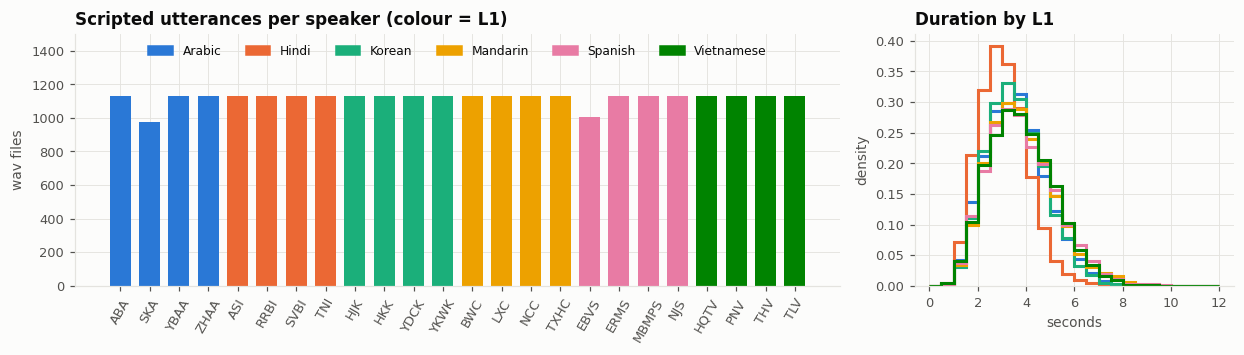

In [15]:
l2 = load_l2arctic()
lu, lp, lw = l2.utts, l2.phones, l2.words
arc = lu[lu.corpus == "arctic"]
suit = lu[lu.corpus == "suitcase"]

spk_tbl = arc.groupby(["l1", "speaker", "gender"]).agg(
    wavs=("utt_id", "size"), hours=("duration_s", lambda s: s.sum() / 3600), annotated=("has_annotation", "sum")).reset_index()
spk_tbl["suitcase"] = spk_tbl.speaker.isin(set(suit.speaker))
spk_tbl["l1"] = pd.Categorical(spk_tbl.l1, eu.L1_ORDER, ordered=True)
spk_tbl = spk_tbl.sort_values(["l1", "speaker"]).reset_index(drop=True)
spk_tbl["hours"] = spk_tbl.hours.round(2)
display(spk_tbl)
display(pd.crosstab(spk_tbl.l1, spk_tbl.gender, margins=True))
print(f"speakers={spk_tbl.speaker.nunique()}  scripted wavs={len(arc):,}  hours={arc.duration_s.sum() / 3600:.2f}  "
      f"mean utt={arc.duration_s.mean():.2f}s  suitcase narratives={len(suit)}  suitcase minutes={suit.duration_s.sum() / 60:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.3), gridspec_kw={"width_ratios": [2.4, 1]})
cols = [eu.L1_COLOR[l] for l in spk_tbl.l1.astype(str)]
axes[0].bar(spk_tbl.speaker, spk_tbl.wavs, color=cols, width=0.72)
axes[0].set_title("Scripted utterances per speaker (colour = L1)"); axes[0].set_ylabel("wav files")
axes[0].tick_params(axis="x", rotation=60)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=eu.L1_COLOR[l], label=l) for l in eu.L1_ORDER], ncol=6, loc="upper center", fontsize=8)
axes[0].set_ylim(0, 1500)
for l1, g in arc.groupby("l1"):
    axes[1].hist(g.duration_s, bins=np.arange(0, 12.5, 0.5), histtype="step", linewidth=2, density=True, color=eu.L1_COLOR[l1])
axes[1].set_title("Duration by L1"); axes[1].set_xlabel("seconds"); axes[1].set_ylabel("density")
fig.tight_layout(); eu.save_fig(fig, "b1_l2arctic_speakers"); plt.show()

KEY["l2arctic"] = {"speakers": int(spk_tbl.speaker.nunique()), "scripted_wavs": int(len(arc)), "hours": round(float(arc.duration_s.sum() / 3600), 2),
                   "mean_utt_s": round(float(arc.duration_s.mean()), 3), "suitcase_narratives": int(len(suit)),
                   "speakers_per_l1": {k: int(v) for k, v in spk_tbl.groupby("l1", observed=True).speaker.nunique().items()},
                   "wavs_per_speaker_min": int(spk_tbl.wavs.min()), "wavs_per_speaker_max": int(spk_tbl.wavs.max())}

In [16]:
print("sample rates:", lu.sample_rate.value_counts().to_dict(), "| channels:", lu.channels.value_counts().to_dict(),
      "| sample width:", lu.sample_width.value_counts().to_dict())
print(f"unreadable headers: {int(lu.duration_s.isna().sum())}")
display(arc.duration_s.describe().round(2).to_frame("scripted duration (s)").T)
print(f"scripted clips < 1 s: {(arc.duration_s < 1).sum()}   > 15 s: {(arc.duration_s > 15).sum()}")
display(suit[["speaker", "l1", "duration_s"]].describe().round(1).T)
mx = spk_tbl.wavs.max()
print("speakers with fewer utterances than the most complete speaker:")
display(spk_tbl.loc[spk_tbl.wavs < spk_tbl.wavs.max() - 5, ["speaker", "l1", "wavs"]].assign(missing=lambda d: mx - d.wavs))
KEY["l2arctic"]["sample_rates"] = {str(k): int(v) for k, v in lu.sample_rate.value_counts().items()}

sample rates: {44100: 26889} | channels: {1: 26889} | sample width: {2: 26889}
unreadable headers: 0


,count,mean,std,min,25%,50%,75%,max
scripted duration (s),26867.0,3.63,1.29,0.68,2.68,3.5,4.43,12.07


scripted clips < 1 s: 41   > 15 s: 0


,count,mean,std,min,25%,50%,75%,max
duration_s,22.0,71.2,41.5,27.6,54.3,64.4,73.0,235.0


speakers with fewer utterances than the most complete speaker:


,speaker,l1,wavs,missing
1,SKA,Arabic,974,158
16,EBVS,Spanish,1007,125


## B2 · Annotation coverage and prompt overlap

Only a small fraction of utterances carry manual error labels; everything else has a forced alignment but **no error information**. Which prompts are annotated, and whether they are shared across speakers, determines how the labelled subset can be split.

In [17]:
ann = arc[arc.has_annotation]
print(f"annotated scripted utterances: {len(ann):,} of {len(arc):,} ({len(ann) / len(arc):.1%})   +  {int(suit.has_annotation.sum())} suitcase files")
print(f"scripted files without forced alignment: {int((~arc.has_forced_alignment).sum())}   annotation files without a wav: {int(lu.wav_path.isna().sum())}")
per_spk_ann = ann.groupby(["l1", "speaker"]).size().rename("annotated").reset_index()
display(per_spk_ann.groupby("l1").annotated.agg(["sum", "min", "max"]))

prompt_spk = ann.groupby("prompt_id").speaker.nunique()
print(f"\ndistinct annotated prompts: {len(prompt_spk)}   (mean {prompt_spk.mean():.2f} speakers per prompt)")
display(prompt_spk.value_counts().sort_index().rename("n_prompts").rename_axis("speakers sharing the prompt").to_frame().T)
print("prompt set of annotated files:", ann.prompt_id.str[:8].value_counts().to_dict())
print("prompts annotated for ALL 24 speakers:", int((prompt_spk == 24).sum()))
# Is each annotated prompt covered for every L1?
l1_cov = ann.groupby("prompt_id").l1.nunique()
print("annotated prompts covering all 6 L1s:", int((l1_cov == 6).sum()), "| covering a single L1 only:", int((l1_cov == 1).sum()))

all_prompts = arc.groupby("prompt_id").speaker.nunique()
print(f"\nscripted prompts: {len(all_prompts)} distinct; read by all 24 speakers: {int((all_prompts == 24).sum())}")
KEY["l2arctic"].update({"annotated_scripted_utts": int(len(ann)), "annotated_suitcase_files": int(suit.has_annotation.sum()),
                        "annotated_share_of_scripted": float(len(ann) / len(arc)), "distinct_annotated_prompts": int(len(prompt_spk)),
                        "annotated_prompts_shared_by_all_speakers": int((prompt_spk == 24).sum()),
                        "annotated_prompts_single_l1": int((l1_cov == 1).sum()), "annotated_prompts_all_l1": int((l1_cov == 6).sum()), "distinct_scripted_prompts": int(len(all_prompts))})

annotated scripted utterances: 3,599 of 26,867 (13.4%)   +  22 suitcase files
scripted files without forced alignment: 0   annotation files without a wav: 0


,sum,min,max
l1,,,
Arabic,599,149,150
Hindi,600,150,150
Korean,600,150,150
Mandarin,600,150,150
Spanish,600,150,150
Vietnamese,600,150,150



distinct annotated prompts: 300   (mean 12.00 speakers per prompt)


speakers sharing the prompt,4,8,12,16,23,24
n_prompts,119,64,15,2,1,99


prompt set of annotated files: {'arctic_a': 2895, 'arctic_b': 704}
prompts annotated for ALL 24 speakers: 99
annotated prompts covering all 6 L1s: 100 | covering a single L1 only: 119

scripted prompts: 1132 distinct; read by all 24 speakers: 954


## B3 · Label sanity checks (parsing the manual annotation tags)

The README warns that tags contain stray whitespace; we also check case, malformed tags, empty intervals and very short segments before trusting any frequency.

In [18]:
ph = lp.copy()
ph["cpl_base"] = ph.cpl.str.replace(r"\d", "", regex=True)
ph["ppl_base"] = ph.ppl.str.replace(r"\d", "", regex=True)
CANON = ["correct", "substitution", "deletion"]
ph["is_slot"] = ph.error_type.isin(CANON)      # a canonical-phone slot (additions have no canonical phone)
ARPABET39 = {"AA","AE","AH","AO","AW","AY","B","CH","D","DH","EH","ER","EY","F","G","HH","IH","IY","JH","K","L","M","N","NG",
             "OW","OY","P","R","S","SH","T","TH","UH","UW","V","W","Y","Z","ZH"}

tagged = ph.label_raw.str.contains(",")
ws = ph.label_raw != ph.label_raw.str.replace(r"\s+", "", regex=True)
print(f"phones-tier intervals: {len(ph):,}  (annotated files: {ph.utt_id.nunique():,})")
print(f"error-tagged labels: {int(tagged.sum()):,} | with stray whitespace: {int((tagged & ws).sum()):,} | "
      f"with upper-case s/d/a tag: {int((tagged & ph.label_raw.str.strip().str[-1].isin(list('SDA'))).sum())} | malformed: {int((ph.error_type == 'malformed').sum())}")
print("silence-marker labels:", ph[ph.error_type == "silence"].cpl.fillna("<empty interval>").value_counts().to_dict())
print("canonical phones outside the 39-phone ARPAbet set:", sorted(set(ph.loc[ph.is_slot, "cpl_base"]) - ARPABET39))
extra = ph.loc[ph.error_type.isin(["substitution", "addition"]), "ppl_base"]
junk = ph.loc[ph.is_slot & ~ph.cpl_base.isin(ARPABET39 | {"AX"}), "cpl_base"]
print(f"canonical labels that look like typos (not ARPAbet, not AX): {len(junk)} tokens -> {junk.value_counts().to_dict()}")
print("canonical 'AX' tokens:", int((ph.loc[ph.is_slot, "cpl_base"] == "AX").sum()), "| perceived 'AX':", int((ph.loc[ph.error_type.isin(["substitution", "addition"]), "ppl_base"] == "AX").sum()))
print("perceived symbols that are not ARPAbet:", extra[~extra.str.rstrip("*").isin(ARPABET39 | {"sil"})].value_counts().head(12).to_dict())
print(f"zero/negative-duration intervals: {int((ph.dur <= 0).sum())} | speech phones shorter than 20 ms: {int((ph.is_slot & (ph.dur < 0.02)).sum())}")
print("intervals not inside any word (word_idx missing), by type:", ph[ph.word_idx.isna()].error_type.value_counts().to_dict())
KEY["l2arctic"]["label_sanity"] = {
    "intervals": int(len(ph)), "error_tagged": int(tagged.sum()), "tagged_with_whitespace": int((tagged & ws).sum()),
    "malformed": int((ph.error_type == "malformed").sum()), "empty_intervals": int((ph.label_raw.str.strip() == "").sum()),
    "nonpositive_duration": int((ph.dur <= 0).sum()), "speech_phones_lt_20ms": int((ph.is_slot & (ph.dur < 0.02)).sum()),
    "canonical_outside_arpabet": sorted(set(ph.loc[ph.is_slot, "cpl_base"]) - ARPABET39), "canonical_typo_tokens": int(len(junk)),
    "tagged_uppercase": int((tagged & ph.label_raw.str.strip().str[-1].isin(list("SDA"))).sum())}

phones-tier intervals: 146,976  (annotated files: 3,621)
error-tagged labels: 20,829 | with stray whitespace: 9,105 | with upper-case s/d/a tag: 182 | malformed: 0
silence-marker labels: {'sp': 9151, 'sil': 3990, '<empty interval>': 3675, 'spn': 3}
canonical phones outside the 39-phone ARPAbet set: ['AX', 'D_', 'ER)', 'V``', 'W`', 'Y_', 'Z_']
canonical labels that look like typos (not ARPAbet, not AX): 6 tokens -> {'ER)': 1, 'D_': 1, 'W`': 1, 'V``': 1, 'Z_': 1, 'Y_': 1}


canonical 'AX' tokens: 19 | perceived 'AX': 348
perceived symbols that are not ARPAbet: {'AX': 348, 'err': 273, 'AH)': 1, 'ER)': 1, 'AH!': 1}


zero/negative-duration intervals: 0 | speech phones shorter than 20 ms: 194


intervals not inside any word (word_idx missing), by type: {'silence': 16775, 'addition': 120, 'correct': 7, 'substitution': 1}


## B4 · Error-type frequency

Rates are expressed **per 100 canonical phones** (correct + substituted + deleted slots), so groups with different amounts of annotated speech are comparable. Our parsed counts are checked against the totals published in the corpus README.

,canonical_phones,substitution,deletion,addition,substitution_per100,deletion_per100,addition_per100,error_rate_%(S+D)
corpus,,,,,,,,
arctic,119151,14098,3420,1092,11.83,2.87,0.92,14.70
suitcase,9824,1673,456,90,17.03,4.64,0.92,21.67


arctic    parsed S/D/A = (14098, 3420, 1092)   README = (14098, 3420, 1092)   MATCH
suitcase  parsed S/D/A = (1673, 456, 90)   README = (1673, 456, 90)   MATCH


,canonical_phones,substitution,deletion,addition,substitution_per100,deletion_per100,addition_per100,error_rate_%(S+D)
l1,,,,,,,,
Arabic,19764,1708,220,274,8.64,1.11,1.39,9.76
Hindi,19737,2420,342,109,12.26,1.73,0.55,13.99
Korean,19686,1560,294,105,7.92,1.49,0.53,9.42
Mandarin,19778,2433,605,206,12.30,3.06,1.04,15.36
Spanish,20050,2822,393,200,14.07,1.96,1.00,16.03
Vietnamese,20136,3155,1566,198,15.67,7.78,0.98,23.45


speaker-level error rate (S+D per 100 phones): min=6.8 (HJK), max=26.5 (THV)


substitutions tagged 'err' (perceived sound unidentified): 262 (1.7%);  accented-variant '*': 1744 (11.1%)


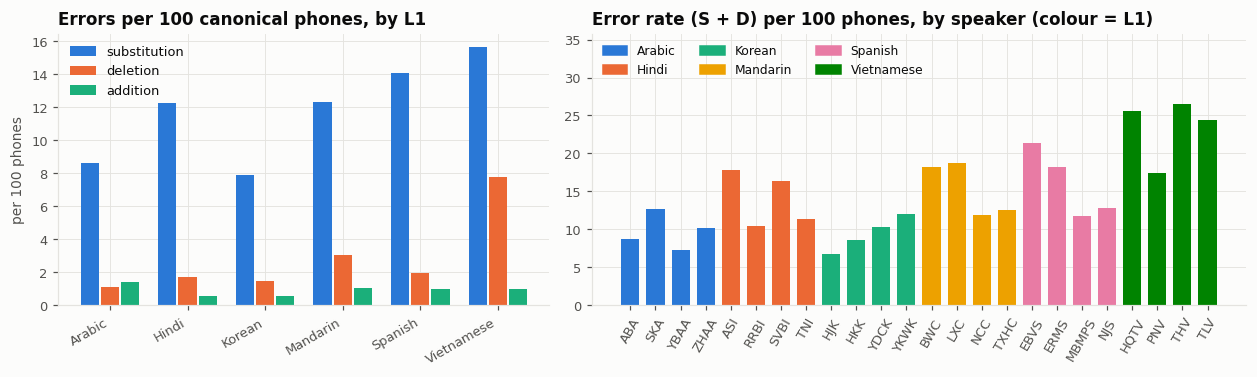

In [19]:
def error_table(df, by):
    cnt = df.groupby([by, "error_type"], observed=True).size().unstack(fill_value=0)
    for c in ["correct", "substitution", "deletion", "addition"]:
        if c not in cnt:
            cnt[c] = 0
    out = pd.DataFrame({"canonical_phones": cnt.correct + cnt.substitution + cnt.deletion,
                        "substitution": cnt.substitution, "deletion": cnt.deletion, "addition": cnt.addition})
    for c in eu.ERROR_ORDER:
        out[f"{c}_per100"] = 100 * out[c] / out.canonical_phones
    out["error_rate_%(S+D)"] = 100 * (out.substitution + out.deletion) / out.canonical_phones
    return out

by_corpus = error_table(ph, "corpus")
display(by_corpus.round(2))
README_COUNTS = {"arctic": (14098, 3420, 1092), "suitcase": (1673, 456, 90)}
for corp, (s, d, a) in README_COUNTS.items():
    got = tuple(int(by_corpus.loc[corp, c]) for c in eu.ERROR_ORDER)
    print(f"{corp:9s} parsed S/D/A = {got}   README = {(s, d, a)}   {'MATCH' if got == (s, d, a) else 'MISMATCH'}")

ph_s = ph[ph.corpus == "arctic"]          # scripted sentences only for L1 / speaker / phone breakdowns
by_l1 = error_table(ph_s, "l1").reindex(eu.L1_ORDER)
by_spk = error_table(ph_s, "speaker")
spk_l1 = ph_s.drop_duplicates("speaker").set_index("speaker").l1
by_spk["l1"] = spk_l1.reindex(by_spk.index)
display(by_l1.round(2))
print(f"speaker-level error rate (S+D per 100 phones): min={by_spk['error_rate_%(S+D)'].min():.1f} ({by_spk['error_rate_%(S+D)'].idxmin()}), "
      f"max={by_spk['error_rate_%(S+D)'].max():.1f} ({by_spk['error_rate_%(S+D)'].idxmax()})")
eu.save_table(by_l1, "l2arctic_error_rates_by_l1"); eu.save_table(by_spk, "l2arctic_error_rates_by_speaker")
sub_ph = ph[ph.error_type == "substitution"]
print(f"substitutions tagged 'err' (perceived sound unidentified): {int(sub_ph.ppl_is_err.sum())} ({sub_ph.ppl_is_err.mean():.1%});  "
      f"accented-variant '*': {int(sub_ph.ppl_is_deviation.sum())} ({sub_ph.ppl_is_deviation.mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.5), gridspec_kw={"width_ratios": [1.2, 1.6]})
x, w = np.arange(len(by_l1)), 0.26
for i, c in enumerate(eu.ERROR_ORDER):
    axes[0].bar(x + (i - 1) * w, by_l1[f"{c}_per100"], w * 0.9, color=eu.ERROR_COLOR[c], label=c)
axes[0].set_xticks(x, by_l1.index, rotation=30, ha="right")
axes[0].set_title("Errors per 100 canonical phones, by L1"); axes[0].set_ylabel("per 100 phones"); axes[0].legend()
bs = by_spk.reset_index().assign(l1=lambda d: pd.Categorical(d.l1, eu.L1_ORDER, ordered=True)).sort_values(["l1", "speaker"])
axes[1].bar(bs.speaker, bs["error_rate_%(S+D)"], color=[eu.L1_COLOR[l] for l in bs.l1.astype(str)], width=0.72)
axes[1].set_title("Error rate (S + D) per 100 phones, by speaker (colour = L1)"); axes[1].tick_params(axis="x", rotation=60)
axes[1].legend(handles=[Patch(color=eu.L1_COLOR[l], label=l) for l in eu.L1_ORDER], ncol=3, loc="upper left", fontsize=8)
axes[1].set_ylim(0, bs["error_rate_%(S+D)"].max() * 1.35)
fig.tight_layout(); eu.save_fig(fig, "b4_l2arctic_error_rates"); plt.show()

KEY["l2arctic"].update({"error_counts_scripted": {c: int(by_corpus.loc["arctic", c]) for c in eu.ERROR_ORDER},
                        "error_counts_suitcase": {c: int(by_corpus.loc["suitcase", c]) for c in eu.ERROR_ORDER},
                        "canonical_phones_scripted": int(by_corpus.loc["arctic", "canonical_phones"]),
                        "error_rate_by_l1": {k: round(float(v), 3) for k, v in by_l1["error_rate_%(S+D)"].items()},
                        "speaker_error_rate_min": round(float(by_spk["error_rate_%(S+D)"].min()), 3),
                        "speaker_error_rate_max": round(float(by_spk["error_rate_%(S+D)"].max()), 3),
                        "sub_tagged_err": int(sub_ph.ppl_is_err.sum()), "sub_tagged_deviation": int(sub_ph.ppl_is_deviation.sum())})

## B5 · What gets substituted, deleted and added

Stress digits are stripped (AH0 and AH1 both become AH) so that confusions are counted per phoneme. `err` marks a sound the annotators could not name; a trailing `*` marks an accented variant of that phoneme.

distinct substitution pairs: 526;  top-20 pairs cover 58.8% of substitutions


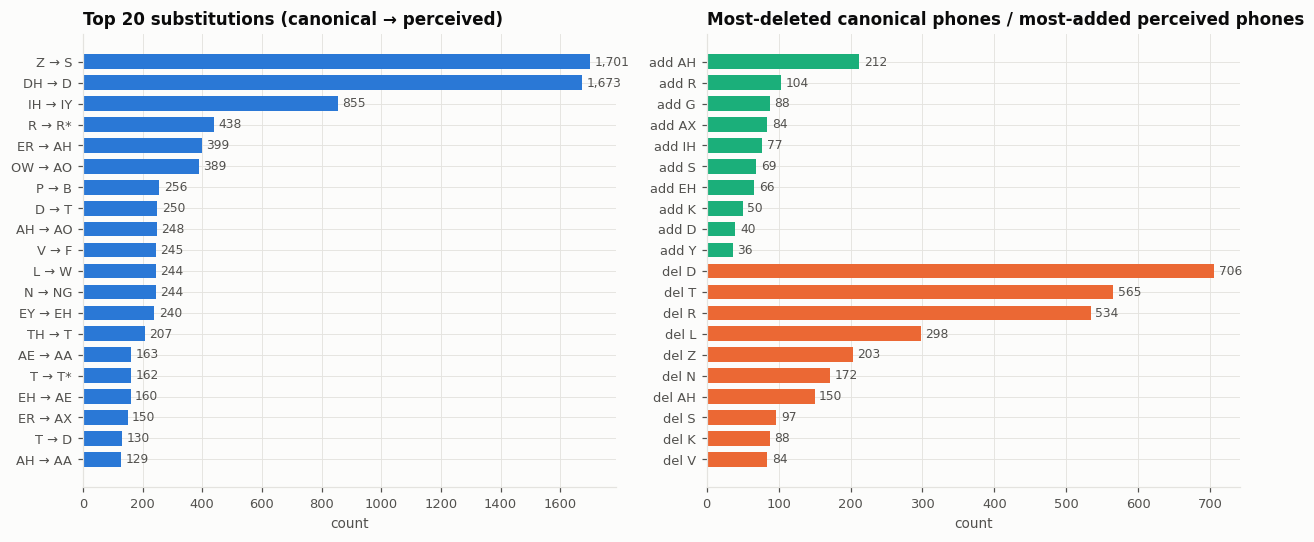

,Arabic,Hindi,Korean,Mandarin,Spanish,Vietnamese
#1,R → R* (289),DH → D (248),DH → D (357),Z → S (386),Z → S (484),DH → D (388)
#2,Z → S (140),Z → S (237),Z → S (296),DH → D (295),IH → IY (353),ER → AH (256)
#3,P → B (101),T → T* (147),IH → IY (114),IH → IY (185),DH → D (330),IH → IY (181)
#4,OW → AO (72),R → R* (123),OW → AO (80),N → NG (152),AE → AA (103),Z → S (158)
#5,DH → Z (63),EY → EH (106),EH → AE (68),L → W (122),N → NG (79),L → W (121)


deletion share of all errors by L1:


l1,Arabic,Hindi,Korean,Mandarin,Spanish,Vietnamese
deletion_share,0.1,0.119,0.15,0.186,0.115,0.318


In [20]:
sub = ph_s[ph_s.error_type == "substitution"]
pair_counts = (sub.cpl_base + " → " + sub.ppl_base).value_counts()
print(f"distinct substitution pairs: {len(pair_counts)};  top-20 pairs cover {pair_counts.head(20).sum() / pair_counts.sum():.1%} of substitutions")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0))
top = pair_counts.head(20)[::-1]
axes[0].barh(top.index, top.values, color=eu.CAT[0], height=0.7)
axes[0].set_title("Top 20 substitutions (canonical → perceived)"); axes[0].set_xlabel("count")
eu.label_bars(axes[0], horizontal=True)

dele = ph_s[ph_s.error_type == "deletion"].cpl_base.value_counts().head(10)[::-1]
add = ph_s[ph_s.error_type == "addition"].ppl_base.value_counts().head(10)[::-1]
axes[1].barh([f"del {p}" for p in dele.index] + [f"add {p}" for p in add.index],
             list(dele.values) + list(add.values), color=[eu.ERROR_COLOR["deletion"]] * len(dele) + [eu.ERROR_COLOR["addition"]] * len(add), height=0.7)
axes[1].set_title("Most-deleted canonical phones / most-added perceived phones"); axes[1].set_xlabel("count")
eu.label_bars(axes[1], horizontal=True)
fig.tight_layout(); eu.save_fig(fig, "b5_l2arctic_confusions"); plt.show()

top_by_l1 = {l1: (g.cpl_base + " → " + g.ppl_base).value_counts().head(5) for l1, g in sub.groupby("l1")}
display(pd.DataFrame({l1: [f"{p} ({c})" for p, c in s.items()] for l1, s in top_by_l1.items()}, index=[f"#{i}" for i in range(1, 6)])[eu.L1_ORDER])
print("deletion share of all errors by L1:")
display((by_l1.deletion / (by_l1.substitution + by_l1.deletion + by_l1.addition)).round(3).to_frame("deletion_share").T)

non-standard canonical labels (excluded from the phoneme-level statistics below): {'AX': 1, 'D_': 1, 'ER)': 1, 'V``': 1, 'W`': 1, 'Y_': 1, 'Z_': 1}
top-5 phonemes by error events (Z, DH, R, D, AH) hold 42.6% of all substitution + deletion events


,canonical_phones,substitution,deletion,error_rate_%(S+D)
cpl_base,,,,
DH,3651,1926,47,54.04
Z,3926,1781,203,50.53
TH,894,372,25,44.41
JH,727,290,14,41.82
ER,3160,887,22,28.77
V,2484,529,84,24.68
R,5097,681,534,23.84
OW,1894,449,1,23.76
D,5612,483,706,21.19


39 canonical phonemes; error counts per phoneme range 8 - 1984; phonemes with < 50 error events: 2, with < 100: 9
vowel vs consonant error rate (S+D per 100): {'consonant': 16.41, 'vowel': 12.06}


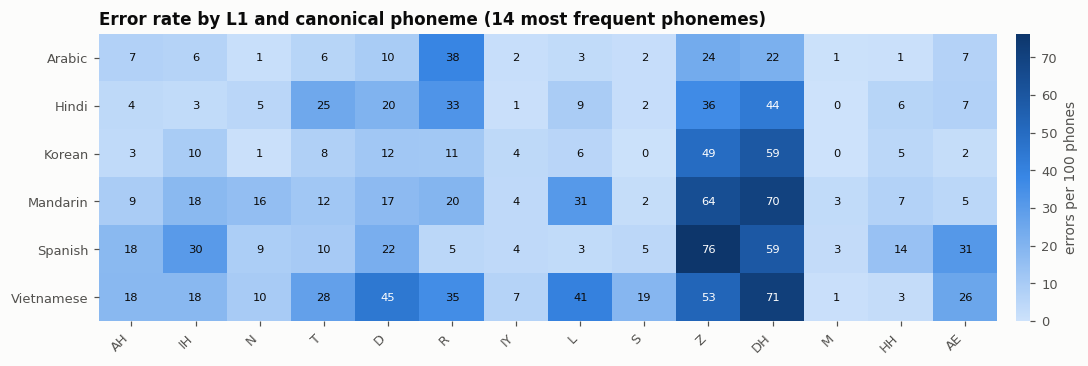

error_type,substitution,deletion,addition
l1,,,
Arabic,1708,220,274
Hindi,2420,342,109
Korean,1560,294,105
Mandarin,2433,605,206
Spanish,2822,393,200
Vietnamese,3155,1566,198


In [21]:
slots = ph_s[ph_s.is_slot]
by_phone_all = error_table(slots, "cpl_base")
by_phone_all["n_errors"] = by_phone_all.substitution + by_phone_all.deletion
by_phone_all["is_vowel"] = by_phone_all.index.isin(eu.VOWELS)
nonstd = by_phone_all[~by_phone_all.index.isin(ARPABET39)]
print("non-standard canonical labels (excluded from the phoneme-level statistics below):", nonstd.canonical_phones.astype(int).to_dict())
by_phone = by_phone_all[by_phone_all.index.isin(ARPABET39)].copy()
top5 = by_phone.n_errors.sort_values(ascending=False).head(5)
print(f"top-5 phonemes by error events ({', '.join(top5.index)}) hold {top5.sum() / by_phone.n_errors.sum():.1%} of all substitution + deletion events")
eligible = by_phone[by_phone.canonical_phones >= 200].sort_values("error_rate_%(S+D)", ascending=False)
display(eligible.head(12)[["canonical_phones", "substitution", "deletion", "error_rate_%(S+D)"]].round(2))
print(f"{len(by_phone)} canonical phonemes; error counts per phoneme range {by_phone.n_errors.min()} - {by_phone.n_errors.max()}; "
      f"phonemes with < 50 error events: {int((by_phone.n_errors < 50).sum())}, with < 100: {int((by_phone.n_errors < 100).sum())}")
print("vowel vs consonant error rate (S+D per 100):", {("vowel" if k else "consonant"): round(float(v), 2) for k, v in
      (100 * by_phone.groupby("is_vowel").n_errors.sum() / by_phone.groupby("is_vowel").canonical_phones.sum()).items()})
eu.save_table(by_phone, "l2arctic_error_rates_by_phone")

# L1 x phoneme heatmap of the 14 most frequent phonemes: where do L1-specific patterns live?
top_ph = by_phone.sort_values("canonical_phones", ascending=False).head(14).index
cell = slots[slots.cpl_base.isin(top_ph)].groupby(["l1", "cpl_base"]).agg(n=("is_slot", "size"), err=("error_type", lambda s: (s != "correct").sum()))
hm = (100 * cell.err / cell.n).where(cell.n >= 30).unstack().reindex(index=eu.L1_ORDER, columns=top_ph)
fig, ax = plt.subplots(figsize=(10, 3.4))
eu.heatmap(ax, hm, fmt="{:.0f}", cbar_label="errors per 100 phones")
ax.set_title("Error rate by L1 and canonical phoneme (14 most frequent phonemes)")
fig.tight_layout(); eu.save_fig(fig, "b5_l2arctic_l1_phoneme_heatmap"); plt.show()

# Rarity of (L1, error type) cells
display(pd.crosstab(ph_s.l1, ph_s.error_type).reindex(index=eu.L1_ORDER)[["substitution", "deletion", "addition"]])

## B6 · Error density at word and utterance level (derived labels)

L2-ARCTIC has no word/utterance scores, but binary "contains an error" indicators can be derived from the phone tags. They are far less imbalanced than phone-level labels, which is useful for choosing the Sprint 3-5 targets.

annotated scripted utterances: 3,599; with no error at all: 130 (3.6%)


,count,mean,std,min,25%,50%,75%,max
errors per utterance,3599.0,5.17,3.51,0.0,3.0,4.0,7.0,23.0


annotated words: 34,000; with >= 1 error: 14,134 (41.6%)


l1,Arabic,Hindi,Korean,Mandarin,Spanish,Vietnamese
share of words with an error,0.302,0.408,0.299,0.445,0.44,0.598


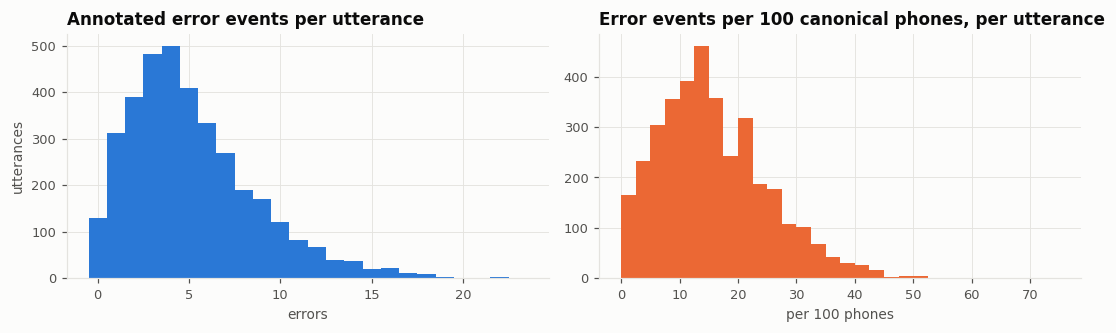

,n_classes,n,majority,majority_share,minority,minority_share,imbalance_ratio,norm_entropy
l2arctic phone type (correct/sub/del/add),4,120243,correct,0.845,addition,0.0091,93.1,0.388
l2arctic phone correct vs error,2,120243,correct,0.845,error,0.1548,5.5,0.622
l2arctic error type among errors (S/D/A),3,18610,substitution,0.758,addition,0.0587,12.9,0.626
l2arctic word has error,2,34000,clean,0.584,error,0.4157,1.4,0.979
l2arctic utterance has error,2,3599,error,0.964,clean,0.0361,26.7,0.224


In [22]:
u_cnt = ph_s.groupby(["utt_id", "error_type"]).size().unstack(fill_value=0)
u_cnt["slots"] = u_cnt.correct + u_cnt.substitution + u_cnt.deletion
u_cnt["errors"] = u_cnt.substitution + u_cnt.deletion + u_cnt.addition
u_cnt["any_error"] = u_cnt.errors > 0
print(f"annotated scripted utterances: {len(u_cnt):,}; with no error at all: {(~u_cnt.any_error).sum()} ({(~u_cnt.any_error).mean():.1%})")
display(u_cnt.errors.describe().round(2).to_frame("errors per utterance").T)

lw_s = lw[lw.corpus == "arctic"].copy()
lw_s["has_error"] = (lw_s.n_sub + lw_s.n_del + lw_s.n_add) > 0
print(f"annotated words: {len(lw_s):,}; with >= 1 error: {lw_s.has_error.sum():,} ({lw_s.has_error.mean():.1%})")
display(lw_s.groupby("l1").has_error.mean().reindex(eu.L1_ORDER).round(3).to_frame("share of words with an error").T)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.1))
axes[0].hist(u_cnt.errors, bins=np.arange(-0.5, u_cnt.errors.max() + 1.5, 1), color=eu.CAT[0])
axes[0].set_title("Annotated error events per utterance"); axes[0].set_xlabel("errors"); axes[0].set_ylabel("utterances")
axes[1].hist(u_cnt.errors / u_cnt.slots * 100, bins=30, color=eu.CAT[1])
axes[1].set_title("Error events per 100 canonical phones, per utterance"); axes[1].set_xlabel("per 100 phones")
fig.tight_layout(); eu.save_fig(fig, "b6_l2arctic_error_density"); plt.show()

IMBALANCE["l2arctic phone type (correct/sub/del/add)"] = eu.imbalance_summary(ph_s[ph_s.error_type.isin(CANON + ["addition"])].error_type.value_counts())
IMBALANCE["l2arctic phone correct vs error"] = eu.imbalance_summary(ph_s[ph_s.error_type.isin(CANON + ["addition"])].error_type.eq("correct").map({True: "correct", False: "error"}).value_counts())
IMBALANCE["l2arctic error type among errors (S/D/A)"] = eu.imbalance_summary(ph_s[ph_s.error_type.isin(eu.ERROR_ORDER)].error_type.value_counts())
IMBALANCE["l2arctic word has error"] = eu.imbalance_summary(lw_s.has_error.map({True: "error", False: "clean"}).value_counts())
IMBALANCE["l2arctic utterance has error"] = eu.imbalance_summary(u_cnt.any_error.map({True: "error", False: "clean"}).value_counts())
imb_l2 = pd.DataFrame({k: v for k, v in IMBALANCE.items() if k.startswith("l2arctic")}).T
display(imb_l2.assign(majority_share=imb_l2.majority_share.astype(float).round(3), minority_share=imb_l2.minority_share.astype(float).round(4),
                      imbalance_ratio=imb_l2.imbalance_ratio.astype(float).round(1), norm_entropy=imb_l2.norm_entropy.astype(float).round(3)))
eu.save_table(imb_l2, "l2arctic_imbalance_summary")
KEY["l2arctic"].update({"annotated_utts_clean_share": float((~u_cnt.any_error).mean()), "annotated_words": int(len(lw_s)),
                        "word_error_share": float(lw_s.has_error.mean()), "phones_lt50_errors": int((by_phone.n_errors < 50).sum()),
                        "phones_lt100_errors": int((by_phone.n_errors < 100).sum()), "n_canonical_phonemes": int(len(by_phone)),
                        "phones_lt50_errors_list": list(by_phone.index[by_phone.n_errors < 50]), "top5_error_phonemes": list(top5.index),
                        "top5_error_share": float(top5.sum() / by_phone.n_errors.sum()),
                        "phone_correct_share": float((ph_s[ph_s.error_type.isin(CANON + ['addition'])].error_type == "correct").mean())})

### Part B takeaways
- Our parsed substitution / deletion / addition counts match the README exactly (scripted: 14,098 / 3,420 / 1,092; suitcase: 1,673 / 456 / 90).
- Only 13.4% of scripted utterances (3,599) carry error labels; 84.5% of annotated phone events are correct, and among errors 75.8% are substitutions and 5.9% additions.
- The error profile is strongly L1-dependent (23.4 errors per 100 phones for Vietnamese vs 9.4 for Korean; deletions are 32% of Vietnamese errors vs 10% of Arabic) and varies widely by speaker (6.8 to 26.5).
- Z and DH are the most error-prone phonemes (about 50-54% of tokens), and the top confusions are Z → S, DH → D and IH → IY.
- 96.4% of annotated utterances contain at least one error, so an utterance-level error flag is not a useful target; word-level (41.6% positive) is.

---
# Part C · Cross-dataset comparison

Where the datasets can be compared at all: the phoneme inventory, and whether phoneme difficulty for Mandarin-L1 speakers is ranked similarly in both (L2-ARCTIC has four Mandarin speakers; SpeechOcean762 is entirely Mandarin).

SpeechOcean762 base phones: 39 | L2-ARCTIC canonical base phones: 46
only in SpeechOcean762: [] | only in L2-ARCTIC: ['AX', 'D_', 'ER)', 'V``', 'W`', 'Y_', 'Z_'] | outside the 39-phone set (SO762): []
stress digits: SO762 vowel tokens carry digits: True | L2-ARCTIC canonical labels carry digits: True
phonemes compared: 36   Spearman rho = 0.50 (p = 0.00204)


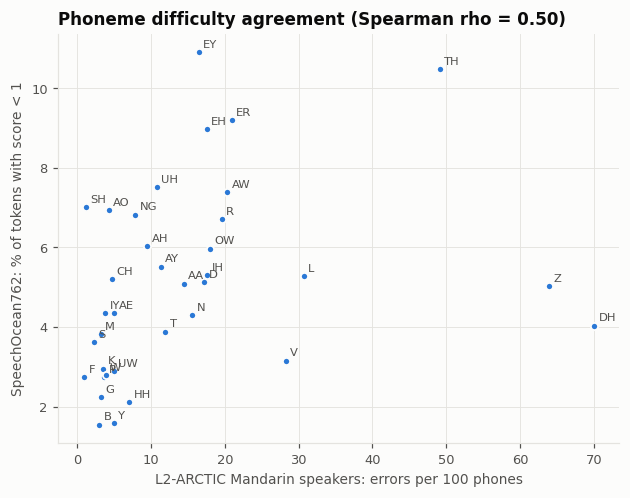

In [23]:
so_ph = set(phones.phone_base)
l2_ph = set(by_phone_all.index)
print(f"SpeechOcean762 base phones: {len(so_ph)} | L2-ARCTIC canonical base phones: {len(l2_ph)}")
print("only in SpeechOcean762:", sorted(so_ph - l2_ph), "| only in L2-ARCTIC:", sorted(l2_ph - so_ph), "| outside the 39-phone set (SO762):", sorted(so_ph - ARPABET39))
print("stress digits: SO762 vowel tokens carry digits:", bool(phones.phone.str.contains(r"\d").any()),
      "| L2-ARCTIC canonical labels carry digits:", bool(ph.loc[ph.is_slot, "cpl"].str.contains(r"\d").any()))

so_diff = phones.groupby("phone_base").score.apply(lambda s: (s < 1).mean()).rename("so762_share_lt1")
so_n = phones.groupby("phone_base").size().rename("so762_n")
l2_man = error_table(slots[slots.l1 == "Mandarin"], "cpl_base")[["canonical_phones", "error_rate_%(S+D)"]].rename(
    columns={"canonical_phones": "l2_mandarin_n", "error_rate_%(S+D)": "l2_mandarin_err_pct"})
cmp_tbl = pd.concat([so_diff, so_n, l2_man], axis=1).dropna()
cmp_tbl = cmp_tbl[(cmp_tbl.so762_n >= 100) & (cmp_tbl.l2_mandarin_n >= 100)]
rho, p = stats.spearmanr(cmp_tbl.so762_share_lt1, cmp_tbl.l2_mandarin_err_pct)
print(f"phonemes compared: {len(cmp_tbl)}   Spearman rho = {rho:.2f} (p = {p:.3g})")

fig, ax = plt.subplots(figsize=(5.8, 4.6))
ax.scatter(cmp_tbl.l2_mandarin_err_pct, 100 * cmp_tbl.so762_share_lt1, s=22, color=eu.CAT[0], edgecolor=eu.SURFACE, linewidth=1.2)
for ph_name, r in cmp_tbl.iterrows():
    ax.annotate(ph_name, (r.l2_mandarin_err_pct, 100 * r.so762_share_lt1), xytext=(3, 3), textcoords="offset points", fontsize=7.5, color=eu.INK_2)
ax.set_xlabel("L2-ARCTIC Mandarin speakers: errors per 100 phones")
ax.set_ylabel("SpeechOcean762: % of tokens with score < 1")
ax.set_title(f"Phoneme difficulty agreement (Spearman rho = {rho:.2f})")
fig.tight_layout(); eu.save_fig(fig, "c_phoneme_difficulty_agreement"); plt.show()
KEY["cross"] = {"so762_base_phones": len(so_ph), "l2_base_phones": len(l2_ph), "l2_nonstandard_labels": int(len(nonstd)), "difficulty_spearman_rho": round(float(rho), 3),
                "difficulty_phonemes_compared": int(len(cmp_tbl))}

---
# Part D · Imbalance and edge-case register

Every finding that should change how we split, weight, evaluate or clean the data, with the evidence computed from the data above. `High` = changes the choice of target or split; `Medium` = needs an explicit mitigation or reporting rule; `Low` = awareness only. Evidence strings are generated from the variables in this notebook, so they cannot drift from the analysis.

In [24]:
REG = []
def flag(id_, dataset, level, severity, finding, evidence, implication):
    REG.append(dict(id=id_, dataset=dataset, level=level, severity=severity, finding=finding, evidence=evidence, implication=implication))

def ag(level, target, col):
    r = agree[(agree.level == level) & (agree.target == target)].iloc[0]
    return float(r[col])

# ---------------------------- SpeechOcean762 ----------------------------
flag("SO-1", "SpeechOcean762", "sentence", "High", "Completeness score is degenerate",
     f"completeness = 10 for {(utts.completeness == 10).mean():.1%} of utterances; only {int((utts.completeness < 10).sum())} of {len(utts):,} are below 10",
     "Do not train or report a completeness head as a regression/classification task; at most keep it as an auxiliary or drop it from the 6-head plan (Sprint 6/7 scope review).")
flag("SO-2", "SpeechOcean762", "word", "High", "Word stress is almost always correct and expert agreement is weak",
     f"{(words.stress == 5).mean():.2%} of words have stress = 5 ({int((words.stress == 5).sum())} of {len(words):,}); pairwise r = {ag('word', 'stress', 'pairwise_r'):.2f}, ICC(2,1) = {ag('word', 'stress', 'icc_2_1'):.2f}",
     "Treat stress as a rare-event detection problem at best; use balanced metrics (balanced accuracy / F1 of the minority class) and expect a very low ceiling. Candidate to drop from the head set.")
flag("SO-3", "SpeechOcean762", "phoneme", "High", "Phone-level labels are heavily skewed toward 'correct'",
     f"{KEY['so762']['expert_phone_label_share']['2']:.1%} of expert labels are 2; consensus score < 0.5 for {KEY['so762']['phone_share_lt05']:.1%} of tokens, < 1.0 for {KEY['so762']['phone_share_lt10']:.1%}; "
     f"imbalance ratio {IMBALANCE['so762 phone consensus < 1.0 vs >= 1.0']['imbalance_ratio']:.0f}:1 (binary at 1.0)",
     "Use weighted loss or resampling and report per-class / balanced metrics; fix and document the binarisation threshold before Sprint 3 (it changes prevalence from 3.6% to 19.3%). Keep phone scores as a regression target as well.")
rare = pt[pt.n < 100]
flag("SO-4", "SpeechOcean762", "phoneme", "Medium", "A few phonemes have very few tokens",
     f"{len(rare)} phonemes with < 100 tokens: " + ", ".join(f"{p} (n={int(n)})" for p, n in rare.n.items()),
     "Exclude from per-phoneme breakdowns (or pool) and avoid reading per-phoneme metrics for them.")
flag("SO-5", "SpeechOcean762", "sentence/word", "Medium", "Sentence and word scores are left-skewed; extremes are rare",
     f"modal sentence 'total' score is 8 ({IMBALANCE['so762 sentence total']['majority_share']:.0%} of utterances); accuracy <= 3 for {int((utts.accuracy <= 3).sum())} utterances; "
     f"{(words.accuracy == 10).mean():.1%} of words score 10, {(words.accuracy <= 6).mean():.1%} score <= 6",
     "Prefer regression with MAE/RMSE/PCC; do not treat the 0-10 scale as 11 classes. Add error-by-score-band reporting so low-score failures are visible (Sprint 3 weakness diagnosis).")
flag("SO-6", "SpeechOcean762", "all", "Medium", "Human agreement bounds attainable performance",
     f"sentence pairwise r = {min(ag('sentence', m, 'pairwise_r') for m in ['accuracy','fluency','prosodic','total']):.2f}-{max(ag('sentence', m, 'pairwise_r') for m in ['accuracy','fluency','prosodic','total']):.2f}; "
     f"leave-one-out r = {min(ag('sentence', m, 'leave_one_out_r') for m in ['accuracy','fluency','prosodic','total']):.2f}-{max(ag('sentence', m, 'leave_one_out_r') for m in ['accuracy','fluency','prosodic','total']):.2f}; "
     f"phone Fleiss kappa = {ag('phone', 'score (0/1/2)', 'fleiss_kappa'):.2f}; consensus accuracy/fluency/prosodic equal the median of the 5 experts in 100% of utterances",
     "Interpret model correlations relative to the leave-one-out ceiling, and report the same agreement figures in the final report as label-noise context.")
ad = shift_tbl[shift_tbl.group == "adult"].iloc[0]
ad = shift_tbl[shift_tbl.group == "adult"].iloc[0]
ch = shift_tbl[shift_tbl.group == "child/teen"].iloc[0]
kp = ks_tbl.drop(index="completeness")["p-value"]
flag("SO-7", "SpeechOcean762", "speaker", "Low", "Train and test differ slightly by age group, but not significantly",
     f"speaker-mean total score: adults train {ad.mean_train:.2f} vs test {ad.mean_test:.2f} (Mann-Whitney p = {ad.p_value:.2f}); child/teen train {ch.mean_train:.2f} vs test {ch.mean_test:.2f} (p = {ch.p_value:.2f}); "
     f"utterance-level KS p-values for the four main scores: {kp.min():.2f}-{kp.max():.2f}",
     "Keep the official test set untouched. The differences are small next to the between-speaker variance (SO-8) and not significant with ~60 speakers per group, but report child/teen and adult results separately and stratify the validation split by age group.")
flag("SO-8", "SpeechOcean762", "speaker", "High", "Most score variance is between speakers",
     "between-speaker share of variance: " + ", ".join(f"{r.target} {r.between_speaker_variance_share:.0%}" for r in spk_var.itertuples()),
     "Splits must be speaker-independent (random utterance splits would leak speaker identity). Validation needs enough speakers (not utterances) to be stable: 125 train speakers, so a ~15% validation set is ~19 speakers.")
pps = utts.groupby("age_group").phones_per_sec.mean()
flag("SO-9", "SpeechOcean762", "speaker", "Medium", "Children and adults differ in prompt length, speaking rate and score spread",
     f"mean words per utterance: child/teen {utts[utts.age_group == 'child/teen'].n_words.mean():.1f} vs adult {utts[utts.age_group == 'adult'].n_words.mean():.1f}; "
     f"phones per second: {pps['child/teen']:.2f} vs {pps['adult']:.2f}; speaker-mean total score std: child/teen {spk_mean[spk_mean.age_group == 'child/teen'].total.std():.2f} vs adult {spk_mean[spk_mean.age_group == 'adult'].total.std():.2f}",
     "A model can use age or prompt-length cues as shortcuts; evaluate within each age group and consider length-matched sanity checks.")
flag("SO-10", "SpeechOcean762", "text", "Low", "A small amount of prompt text is shared between train and test",
     f"{KEY['so762']['test_utts_prompt_seen_in_train']} test utterances ({KEY['so762']['test_utts_prompt_seen_in_train'] / KEY['so762']['test_utts']:.1%}) have a prompt that also occurs in train; {KEY['so762']['unique_prompts']:,} distinct prompts for 5,000 utterances",
     "Negligible leakage risk; note it in the report. No text-disjoint split is required for this dataset.")
big = utts[utts.duration_s > 15]
flag("SO-11", "SpeechOcean762", "audio", "Low", "A few long clips; audio format is uniform",
     f"longest clip {utts.duration_s.max():.1f} s (train) vs {utts[utts.split == 'test'].duration_s.max():.1f} s in test; {len(big)} clips > 15 s from {big.speaker.nunique()} speakers (age groups: {', '.join(sorted(big.age_group.unique()))}); all audio is already 16 kHz mono 16-bit",
     "Set a max length for batching (about 20.5 s covers everything); no resampling needed for this dataset.")
flag("SO-12", "SpeechOcean762", "phoneme", "Medium", "Error-type information is thin and mostly 'deleted' or 'unrecognisable'",
     f"only {KEY['so762']['phone_tokens_with_pronounced_label']:,} phone tokens ({KEY['so762']['phone_tokens_with_pronounced_label'] / KEY['so762']['phone_tokens']:.1%}) carry a pronounced-phone label; {int((mp.pronounced == '<DEL>').sum())} are <DEL> and {int((mp.pronounced == '<unk>').sum())} are <unk>",
     "Use L2-ARCTIC (not SpeechOcean762) for error-type classification; SpeechOcean762 supports scoring tasks only.")
flag("SO-13", "SpeechOcean762", "L1", "Medium", "Single native language",
     "all 250 speakers are Mandarin L1 (per the corpus README)",
     "Generalisation across L1 backgrounds cannot be tested on this dataset; that question depends on L2-ARCTIC (Sprint 8).")

# ---------------------------- L2-ARCTIC ----------------------------
flag("LA-1", "L2-ARCTIC", "all", "High", "Error labels exist for a small fraction of the audio",
     f"{KEY['l2arctic']['annotated_scripted_utts']:,} of {KEY['l2arctic']['scripted_wavs']:,} scripted utterances ({KEY['l2arctic']['annotated_share_of_scripted']:.1%}) plus {KEY['l2arctic']['annotated_suitcase_files']} suitcase narratives are manually annotated; the rest have forced alignment only",
     "Supervised error-type training and evaluation use only the annotated subset (about 120k phone events); the other 87% of the audio is useful only for self-supervised or pseudo-label use. State this scope in the report.")
flag("LA-2", "L2-ARCTIC", "phoneme", "High", "Phone-level error labels are skewed and the rare classes are very rare",
     f"correct = {KEY['l2arctic']['phone_correct_share']:.1%} of phone events; among errors: substitution {IMBALANCE['l2arctic error type among errors (S/D/A)']['majority_share']:.1%}, addition only "
     f"{IMBALANCE['l2arctic error type among errors (S/D/A)']['minority_share']:.1%} ({KEY['l2arctic']['error_counts_scripted']['addition']:,}); 4-class imbalance ratio {IMBALANCE['l2arctic phone type (correct/sub/del/add)']['imbalance_ratio']:.0f}:1",
     "Use class weights / focal loss or resampling and macro-F1 / per-class recall. Report additions and deletions separately from substitutions. Resampling must happen inside the training split only.")
few = by_phone[by_phone.n_errors < 50]
flag("LA-3", "L2-ARCTIC", "phoneme", "Medium", "Error support is uneven across phonemes",
     f"top-5 phonemes ({', '.join(KEY['l2arctic']['top5_error_phonemes'])}) hold {KEY['l2arctic']['top5_error_share']:.0%} of substitution + deletion events; "
     f"{len(few)} of {len(by_phone)} standard phonemes have < 50 error events ({', '.join(few.index) or 'none'}) and {KEY['l2arctic']['phones_lt100_errors']} have < 100; highest error rates: " + ", ".join(f"{p} {r:.0f}%" for p, r in eligible.head(4)["error_rate_%(S+D)"].items()),
     "Per-phoneme classifiers are not viable for the low-support phonemes; group phonemes (manner / place classes) for error-type tasks and show per-phoneme support next to every per-phoneme metric.")
l1_sp = by_spk.groupby("l1", observed=True)["error_rate_%(S+D)"].agg(["min", "max"])
flag("LA-4", "L2-ARCTIC", "L1/speaker", "High", "Error profile depends strongly on L1 and on the individual speaker",
     f"error rate per 100 phones: " + ", ".join(f"{k} {v:.1f}" for k, v in by_l1['error_rate_%(S+D)'].items()) + f"; deletion share of errors {by_l1.deletion.div(by_l1[['substitution','deletion','addition']].sum(axis=1)).min():.0%}-{by_l1.deletion.div(by_l1[['substitution','deletion','addition']].sum(axis=1)).max():.0%}; "
     f"speaker range {KEY['l2arctic']['speaker_error_rate_min']:.1f}-{KEY['l2arctic']['speaker_error_rate_max']:.1f}",
     "Aggregate metrics will hide weak L1 groups; report every L2-ARCTIC result per L1 (and per speaker where useful). This is the data basis for the Sprint 8 generalisation story.")
flag("LA-5", "L2-ARCTIC", "speaker", "High", "Only 24 speakers (4 per L1): any speaker-independent split is statistically thin",
     f"{KEY['l2arctic']['speakers']} speakers; 4 per L1 (2 F + 2 M); annotated utterances per speaker 149-150",
     "A single fixed test set of a few speakers gives high-variance estimates. Prefer grouped (speaker-held-out) cross-validation, stratified by L1 and gender, or hold out 1 speaker per L1 for test with 1 per L1 for validation. Save speaker lists per fold for audit.")
flag("LA-6", "L2-ARCTIC", "text", "Medium", "Annotated prompts are shared across speakers, so text cannot be disjoint under a speaker split",
     f"{KEY['l2arctic']['distinct_annotated_prompts']} distinct annotated prompts; {KEY['l2arctic']['annotated_prompts_shared_by_all_speakers']} annotated for all 24 speakers; {KEY['l2arctic']['annotated_prompts_single_l1']} annotated only for one L1's 4 speakers (L1-targeted sentences) and {KEY['l2arctic']['annotated_prompts_all_l1']} covering all six L1s",
     "Speaker-independent splits will repeat sentence text across partitions; acceptable for pronunciation assessment but state it. Do not stratify by prompt.")
flag("LA-7", "L2-ARCTIC", "labels", "Medium", "Annotation tags are inconsistently formatted and contain typos",
     f"{KEY['l2arctic']['label_sanity']['tagged_with_whitespace']:,} of {KEY['l2arctic']['label_sanity']['error_tagged']:,} error tags contain stray whitespace; {KEY['l2arctic']['label_sanity']['tagged_uppercase']} use upper-case s/d/a; "
     f"{KEY['l2arctic']['label_sanity']['canonical_typo_tokens']} canonical labels are typos ({', '.join(x for x in KEY['l2arctic']['label_sanity']['canonical_outside_arpabet'] if x != 'AX')}); {KEY['l2arctic']['label_sanity']['empty_intervals']:,} empty phone intervals",
     "Always read tags through `parse_phone_label`; in US 2.2 add an explicit mapping of the typo labels to the 39-phone inventory and a validation step that fails on unknown symbols.")
flag("LA-8", "L2-ARCTIC", "labels", "Medium", "Policy decisions needed for 'err' and '*' perceived tags",
     f"{KEY['l2arctic']['sub_tagged_err']} substitutions are tagged 'err' (sound not identified) and {KEY['l2arctic']['sub_tagged_deviation']:,} carry '*' (accented variant of the phone)",
     "Decide and document: treat '*' as an error (accented deviation) or as correct-with-accent, and map 'err' to a generic substitution class. The choice changes substitution counts by about 11%.")
flag("LA-9", "L2-ARCTIC", "utterance", "Medium", "Utterance-level 'has an error' label is almost always positive",
     f"{1 - KEY['l2arctic']['annotated_utts_clean_share']:.1%} of annotated utterances contain at least one error; mean {u_cnt.errors.mean():.1f} error events per utterance",
     "Do not use binary utterance-level error detection as a target; use error rate / count regression. Word-level 'has error' is far more balanced and is a reasonable derived target.")
flag("LA-10", "L2-ARCTIC", "domain", "Medium", "Suitcase (spontaneous) subset is a different domain and very small",
     f"{KEY['l2arctic']['suitcase_narratives']} narratives, 26.1 minutes; error rate {by_corpus.loc['suitcase', 'error_rate_%(S+D)']:.1f} vs {by_corpus.loc['arctic', 'error_rate_%(S+D)']:.1f} per 100 phones in scripted speech; no forced-alignment TextGrid",
     "Keep it out of training and validation; use it only as an optional out-of-domain evaluation.")
flag("LA-11", "L2-ARCTIC", "audio", "Low", "Sampling rate and a few audio irregularities",
     f"all audio is 44.1 kHz mono (SpeechOcean762 is 16 kHz); {int((arc.duration_s < 1).sum())} scripted clips < 1 s; SKA has {int(spk_tbl.set_index('speaker').loc['SKA', 'wavs'])} and EBVS {int(spk_tbl.set_index('speaker').loc['EBVS', 'wavs'])} utterances (others ~1,130)",
     "Resample to 16 kHz in US 2.2 for compatibility with the pretrained encoders and SpeechOcean762. Uneven per-speaker counts are harmless for the annotated subset (149-150 each).")
flag("LA-12", "L2-ARCTIC", "alignment", "Low", "Small numbers of segments outside word boundaries or very short",
     f"{int(((ph.word_idx.isna()) & (ph.error_type == 'addition')).sum())} addition intervals and {int(((ph.word_idx.isna()) & (ph.error_type == 'correct')).sum())} correct phones fall outside any word interval; {KEY['l2arctic']['label_sanity']['speech_phones_lt_20ms']} speech phones are shorter than 20 ms",
     "Check these during the US 2.2 alignment validation; additions between words need an explicit attachment rule (e.g. to the following word).")

# ---------------------------- Cross-dataset ----------------------------
flag("X-1", "both", "task design", "High", "Label schemes do not overlap: scores vs categorical error tags",
     "SpeechOcean762 has sentence/word/phoneme scores; L2-ARCTIC has phone-level error types only (no sentence or word scores)",
     "Model each dataset with its own heads. Multi-task learning (Sprint 6) can share an encoder across datasets but not a joint label set; plan the 6-head scope around this (Sprint 7 scope review).")
flag("X-2", "both", "phoneme inventory", "Medium", "Phoneme symbols need unification",
     f"SpeechOcean762 uses {KEY['cross']['so762_base_phones']} ARPAbet base phones with stress digits; L2-ARCTIC canonical labels contain {KEY['cross']['l2_base_phones']} symbols ({KEY['cross']['l2_nonstandard_labels']} non-standard: AX and typo labels); phoneme-difficulty agreement for Mandarin speakers: Spearman rho = {KEY['cross']['difficulty_spearman_rho']:.2f} over {KEY['cross']['difficulty_phonemes_compared']} phonemes",
     "Map both to a common 39-phone inventory (stress kept as a separate feature) in US 2.2. A moderate rho means phoneme difficulty transfers only partly between the corpora.")
flag("X-3", "both", "speakers", "Medium", "Different speaker populations",
     f"SpeechOcean762: {KEY['so762']['child_speakers']} child/teen + {KEY['so762']['adult_speakers']} adult Mandarin speakers; L2-ARCTIC: 24 adults across 6 L1s",
     "Cross-dataset conclusions mix age, L1 and recording conditions; avoid attributing differences to a single factor.")

register = pd.DataFrame(REG)
sev_order = {"High": 0, "Medium": 1, "Low": 2}
register = register.sort_values(["severity", "id"], key=lambda c: c.map(sev_order) if c.name == "severity" else c, kind="stable").reset_index(drop=True)
print(register.severity.value_counts().to_dict())
pd.set_option("display.max_colwidth", 200)
display(register[["id", "dataset", "severity", "finding"]])
eu.save_table(register, "imbalance_edge_case_register", index=False)

{'Medium': 14, 'High': 9, 'Low': 5}

,id,dataset,severity,finding
0,LA-1,L2-ARCTIC,High,Error labels exist for a small fraction of the audio
1,LA-2,L2-ARCTIC,High,Phone-level error labels are skewed and the rare classes are very rare
2,LA-4,L2-ARCTIC,High,Error profile depends strongly on L1 and on the individual speaker
3,LA-5,L2-ARCTIC,High,Only 24 speakers (4 per L1): any speaker-independent split is statistically thin
4,SO-1,SpeechOcean762,High,Completeness score is degenerate
5,SO-2,SpeechOcean762,High,Word stress is almost always correct and expert agreement is weak
6,SO-3,SpeechOcean762,High,Phone-level labels are heavily skewed toward 'correct'
7,SO-8,SpeechOcean762,High,Most score variance is between speakers
8,X-1,both,High,Label schemes do not overlap: scores vs categorical error tags
9,LA-10,L2-ARCTIC,Medium,Suitcase (spontaneous) subset is a different domain and very small


PosixPath('/sessions/rcw-01gomj9way6vkau3uc5comir/mnt/esl-pronunciation-assessment/results/tables/eda/imbalance_edge_case_register.csv')

## Implications for US 2.2 (splits and preprocessing) and for the modelling plan

1. **SpeechOcean762**: keep the official test set as is. Build validation from the train speakers only, stratified by age group × gender × speaker-mean score (SO-8, SO-9). Never split by utterance.
2. **L2-ARCTIC**: use speaker-grouped folds stratified by L1 and gender rather than a single tiny hold-out (LA-5). Restrict supervised error-type work to the annotated subset (LA-1) and exclude the suitcase files from training (LA-10).
3. **Targets**: SpeechOcean762 sentence accuracy / fluency / prosodic / total and word accuracy are viable regression targets; completeness and word stress are not (SO-1, SO-2). L2-ARCTIC phone error type and derived word-level "has error" are viable; utterance-level "has error" is not (LA-9).
4. **Imbalance handling** belongs inside each training split only (class weights or resampling), and every classification result is reported with macro-F1 / balanced accuracy and per-class support (SO-3, LA-2, LA-3).
5. **Reporting rules** carried into Sprint 3 onward: per age group (SO-7, SO-9), per L1 (LA-4), against the human-agreement ceiling (SO-6).
6. **US 2.2 cleaning decisions to make**: the `*` / `err` tag policy (LA-8), the typo-label mapping (LA-7), the common 39-phone inventory (X-2), resampling to 16 kHz (LA-11), and the attachment rule for additions between words (LA-12).

In [25]:
OUT = eu.TABLE_DIR
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "key_stats.json").write_text(json.dumps(KEY, indent=2, default=str))
print("wrote", OUT / "key_stats.json")
print("figures:", sorted(p.name for p in eu.FIG_DIR.glob("*.png")))
print("tables:", sorted(p.name for p in eu.TABLE_DIR.glob("*")))

wrote /sessions/rcw-01gomj9way6vkau3uc5comir/mnt/esl-pronunciation-assessment/results/tables/eda/key_stats.json
figures: ['a1_so762_speakers.png', 'a2_so762_duration.png', 'a4_so762_sentence_corr.png', 'a4_so762_sentence_scores.png', 'a5_so762_word_scores.png', 'a6_so762_phone_difficulty.png', 'a6_so762_phone_scores.png', 'a8_so762_speaker_means.png', 'b1_l2arctic_speakers.png', 'b4_l2arctic_error_rates.png', 'b5_l2arctic_confusions.png', 'b5_l2arctic_l1_phoneme_heatmap.png', 'b6_l2arctic_error_density.png', 'c_phoneme_difficulty_agreement.png']
tables: ['imbalance_edge_case_register.csv', 'key_stats.json', 'l2arctic_error_rates_by_l1.csv', 'l2arctic_error_rates_by_phone.csv', 'l2arctic_error_rates_by_speaker.csv', 'l2arctic_imbalance_summary.csv', 'so762_annotator_agreement.csv', 'so762_imbalance_summary.csv', 'so762_phone_binarisation_prevalence.csv', 'so762_phone_difficulty.csv', 'so762_sentence_score_summary.csv']
